# Отбор признаков и валидация моделей

Разбор на линейной и логистической регрессии.

Ноутбук отвечает на три вопроса:

1. Почему лишние признаки ухудшают модель, хотя формально добавляют информацию.
2. Как измерить качество так, чтобы оценка не оказалась завышенной.
3. Какие методы отбора признаков существуют, что каждый из них реально оптимизирует и при каких условиях ломается.

Порядок частей неслучаен: сначала валидация, потом отбор. Отбор признаков без корректной схемы валидации бессмыслен, потому что нечем сравнивать варианты, а некорректная схема валидации систематически выбирает худший вариант.

Что нужно знать заранее: матричное умножение, базовая теория вероятностей, синтаксис numpy и sklearn.

## Содержание

* Часть I. Почему лишние признаки вредны: разложение ошибки, рост дисперсии оценок, мультиколлинеарность.
* Часть II. Валидация: отложенная выборка, кросс-валидация, утечка данных, вложенная кросс-валидация.
* Часть III. Линейная регрессия: метрики, фильтры, обёртки, Ridge, Lasso, ElasticNet, устойчивость отбора.
* Часть IV. Логистическая регрессия: метрики классификации, дисбаланс, L1-отбор, порог принятия решения, калибровка.
* Часть V. Чек-лист, таблица типичных ошибок, выбор метода под задачу.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification, load_diabetes, load_breast_cancer
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression,
                                  LassoCV, lasso_path)
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, cross_val_score,
                                     cross_validate, GridSearchCV, validation_curve, learning_curve)
from sklearn.feature_selection import (SelectKBest, SelectFromModel, f_regression, f_classif,
                                       mutual_info_regression, RFE, RFECV, SequentialFeatureSelector)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, log_loss, brier_score_loss,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 150)
pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110

SEED = 42

# Часть I. Почему лишние признаки вредны

## 1.1 Разложение ошибки на смещение и разброс

Пусть данные порождаются как $y = f(x) + \varepsilon$, где $\mathbb{E}[\varepsilon]=0$ и $\mathrm{Var}(\varepsilon)=\sigma^2$. Модель $\hat f_D$ обучается на случайной выборке $D$. Ожидаемая квадратичная ошибка в точке $x_0$ раскладывается на три слагаемых:

$$\mathbb{E}_D\big[(y_0 - \hat f_D(x_0))^2\big] \;=\; \underbrace{\big(\mathbb{E}_D[\hat f_D(x_0)] - f(x_0)\big)^2}_{\text{смещение}^2} \;+\; \underbrace{\mathrm{Var}_D\big(\hat f_D(x_0)\big)}_{\text{разброс}} \;+\; \underbrace{\sigma^2}_{\text{шум}}$$

Третье слагаемое неустранимо: это предел качества любой модели. Первые два управляются сложностью модели и управляются в противоположные стороны.

Ключевое наблюдение для линейных моделей: добавление признака **никогда не увеличивает смещение**, потому что старая модель вложена в новую (достаточно занулить новый коэффициент). И почти всегда **увеличивает разброс**. Если признак не несёт сигнала, первое слагаемое не уменьшается вовсе, а второе растёт. Отбор признаков это способ намеренно добавить немного смещения ради заметного снижения разброса.

## 1.2 Разброс МНК явно зависит от числа признаков

Для модели $y = X\beta + \varepsilon$ оценка метода наименьших квадратов равна

$$\hat\beta = (X^\top X)^{-1} X^\top y, \qquad \mathrm{Var}(\hat\beta) = \sigma^2 (X^\top X)^{-1}$$

Ожидаемая ошибка предсказания на обучающих точках относительно истинной функции равна

$$\mathbb{E}\left[\frac{1}{n}\sum_{i=1}^{n} \big(\hat y_i - f(x_i)\big)^2\right] = \frac{p}{n}\,\sigma^2$$

где $p$ это число признаков, $n$ это число объектов. Каждый добавленный признак вносит фиксированный вклад $\sigma^2/n$ **независимо от того, полезен он или нет**. Полезный признак этот вклад окупает уменьшением смещения, бесполезный не окупает ничем.

Отсюда три режима:

* $p \ll n$: вклад дисперсии мал, можно позволить себе лишние признаки.
* $p \to n$: модель проходит ровно через обучающие точки, ошибка на обучении обращается в ноль, ошибка на новых данных расходится.
* $p > n$: матрица $X^\top X$ вырождена, решение МНК не единственно, метод неприменим без регуляризации.

Проверим это напрямую. Возьмём 120 объектов, из которых 84 в обучении. Первые 5 признаков несут сигнал, остальные 85 это чистый шум, не связанный с целевой переменной. Будем добавлять шумовые признаки по одному и смотреть, что происходит с $R^2$ на обучении и на тесте.

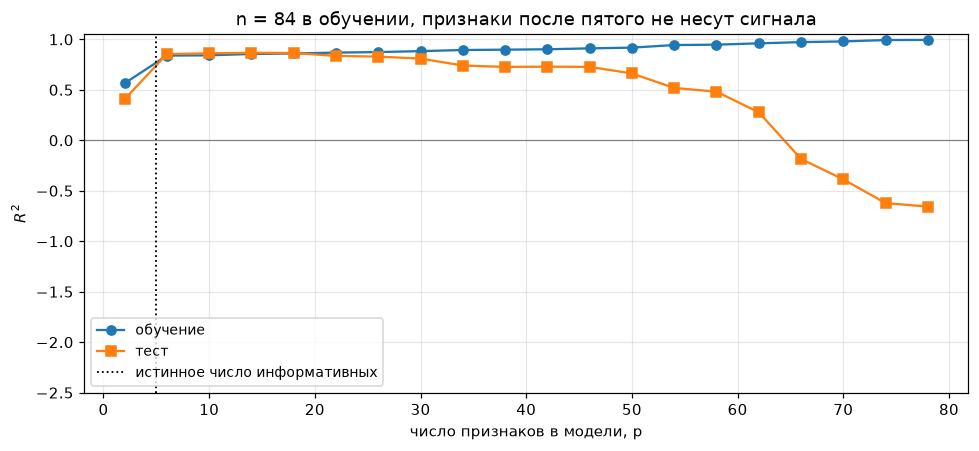

 p  R2 обучение  R2 тест
 2        0.565    0.407
 6        0.839    0.855
14        0.856    0.867
30        0.883    0.809
46        0.911    0.727
62        0.961    0.278
78        0.995   -0.657


In [2]:
rng = np.random.default_rng(SEED)
n_samples, n_true = 120, 5

X_pool = rng.normal(size=(n_samples, 90))
beta_true = np.zeros(90)
beta_true[:n_true] = [3.0, -2.0, 1.5, 2.5, -1.0]
y_pool = X_pool @ beta_true + rng.normal(scale=2.0, size=n_samples)

Xtr, Xte, ytr, yte = train_test_split(X_pool, y_pool, test_size=0.3, random_state=SEED)

grid_p = list(range(2, 81, 4))
train_r2, test_r2 = [], []
for p in grid_p:
    model = LinearRegression().fit(Xtr[:, :p], ytr)
    train_r2.append(r2_score(ytr, model.predict(Xtr[:, :p])))
    test_r2.append(r2_score(yte, model.predict(Xte[:, :p])))

fig, ax = plt.subplots()
ax.plot(grid_p, train_r2, "o-", label="обучение")
ax.plot(grid_p, test_r2, "s-", label="тест")
ax.axvline(n_true, color="k", ls=":", lw=1.2, label="истинное число информативных")
ax.axhline(0.0, color="0.5", lw=0.8)
ax.set_xlabel("число признаков в модели, p")
ax.set_ylabel("$R^2$")
ax.set_ylim(-2.5, 1.05)
ax.set_title("n = 84 в обучении, признаки после пятого не несут сигнала")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

res = pd.DataFrame({"p": grid_p, "R2 обучение": train_r2, "R2 тест": test_r2})
print(res.iloc[[0, 1, 3, 7, 11, 15, 19]].to_string(index=False))

При $p=6$ модель содержит все информативные признаки, $R^2$ на тесте максимален. Дальше каждый добавленный шумовой признак поднимает $R^2$ на обучении и опускает на тесте. К $p=78$ обучающий $R^2$ практически равен единице, а тестовый уходит глубоко в минус: модель хуже, чем предсказание константой.

Здесь важно понять механизм. Шумовой признак не связан с $y$ в генеральной совокупности, но на конкретных 84 объектах выборочная корреляция не равна нулю. МНК подбирает под неё коэффициент, и этот коэффициент есть чистая подгонка под шум конкретной выборки. На новых данных та же случайная корреляция не воспроизводится, и вклад признака становится отрицательным.

Разрыв между обучающей и тестовой кривой это и есть переобучение. Он растёт как $p/n$, ровно как предсказывает формула выше.

## 1.3 Мультиколлинеарность

Второй источник проблем это линейная зависимость между признаками. Если один признак хорошо предсказывается остальными, матрица $X^\top X$ близка к вырожденной, и дисперсия отдельных коэффициентов взрывается:

$$\mathrm{Var}(\hat\beta_j) = \frac{\sigma^2}{n\,\mathrm{Var}(x_j)}\cdot\underbrace{\frac{1}{1 - R_j^2}}_{\mathrm{VIF}_j}$$

где $R_j^2$ это коэффициент детерминации регрессии признака $x_j$ на все остальные признаки. Множитель $\mathrm{VIF}_j$ называется фактором инфляции дисперсии. При $R_j^2 = 0.99$ дисперсия коэффициента в сто раз больше, чем была бы при независимых признаках.

Практические следствия:

* Коэффициенты меняют величину и даже знак при малом изменении выборки. Интерпретация коэффициентов теряет смысл.
* **Качество предсказания при этом может не страдать.** Модель компенсирует один признак другим, и сумма их вкладов остаётся устойчивой, хотя каждое слагаемое по отдельности скачет.
* Отбор среди коллинеарных признаков нестабилен: какой именно представитель группы будет выбран, определяется случайностью выборки.

Порог $\mathrm{VIF} > 10$ часто называют признаком проблемы, но это эмпирическое правило без теоретического обоснования, а не критерий.

Смоделируем: $x_1$ и $x_2$ это две зашумлённые копии одного скрытого фактора $u$, а целевая переменная зависит именно от $u$. Признак $x_3$ независим и бесполезен. Посмотрим на разброс коэффициентов по 300 бутстрап-выборкам.

VIF: {'x1': np.float64(39.5), 'x2': np.float64(39.4), 'x3': np.float64(1.0)}

    МНК среднее  МНК std  Ridge среднее  Ridge std
x1        0.546    0.265          0.701      0.175
x2        1.476    0.259          1.315      0.170
x3        0.007    0.044          0.009      0.043

std отдельного коэффициента при x1 : 0.265
std суммы коэффициентов x1 + x2    : 0.041


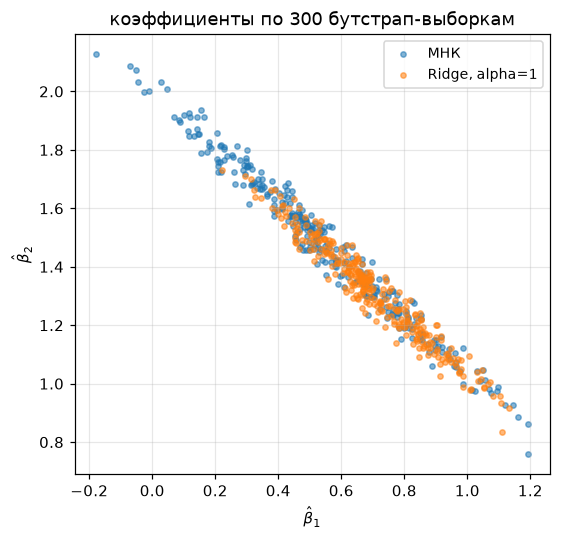

In [3]:
rng = np.random.default_rng(SEED)
n = 200
u = rng.normal(size=n)
X_col = np.column_stack([
    u + rng.normal(scale=0.1, size=n),
    u + rng.normal(scale=0.1, size=n),
    rng.normal(size=n),
])
y_col = 2.0 * u + rng.normal(scale=0.5, size=n)


def vif(X):
    out = []
    for j in range(X.shape[1]):
        other = np.delete(X, j, axis=1)
        r2 = LinearRegression().fit(other, X[:, j]).score(other, X[:, j])
        out.append(1.0 / (1.0 - r2))
    return np.array(out)


print("VIF:", dict(zip(["x1", "x2", "x3"], vif(X_col).round(1))))

coefs_ols, coefs_ridge = [], []
for _ in range(300):
    idx = rng.integers(0, n, n)
    coefs_ols.append(LinearRegression().fit(X_col[idx], y_col[idx]).coef_)
    coefs_ridge.append(Ridge(alpha=1.0).fit(X_col[idx], y_col[idx]).coef_)
coefs_ols = np.asarray(coefs_ols)
coefs_ridge = np.asarray(coefs_ridge)

summary = pd.DataFrame(
    {
        "МНК среднее": coefs_ols.mean(0),
        "МНК std": coefs_ols.std(0),
        "Ridge среднее": coefs_ridge.mean(0),
        "Ridge std": coefs_ridge.std(0),
    },
    index=["x1", "x2", "x3"],
)
print()
print(summary)
print()
print(f"std отдельного коэффициента при x1 : {coefs_ols[:, 0].std():.3f}")
print(f"std суммы коэффициентов x1 + x2    : {(coefs_ols[:, 0] + coefs_ols[:, 1]).std():.3f}")

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(coefs_ols[:, 0], coefs_ols[:, 1], s=12, alpha=0.55, label="МНК")
ax.scatter(coefs_ridge[:, 0], coefs_ridge[:, 1], s=12, alpha=0.55, label="Ridge, alpha=1")
ax.set_xlabel(r"$\hat\beta_1$")
ax.set_ylabel(r"$\hat\beta_2$")
ax.set_title("коэффициенты по 300 бутстрап-выборкам")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Отдельные коэффициенты гуляют в диапазоне порядка десяти единиц, тогда как их сумма устойчива с точностью до сотых. Облако точек на графике вытянуто вдоль прямой $\beta_1 + \beta_2 = \mathrm{const}$: данные жёстко определяют сумму и почти ничего не говорят о том, как разделить её между двумя почти одинаковыми признаками.

Ridge стягивает облако в компактную область около точки, где вклад разделён поровну. Это прямое следствие формы штрафа: при фиксированной сумме $\beta_1+\beta_2=s$ величина $\beta_1^2+\beta_2^2$ минимальна при $\beta_1=\beta_2=s/2$. L2-штраф не просто уменьшает коэффициенты, он предпочитает равномерное распределение вклада между коррелированными признаками.

Вывод для практики: если по коэффициентам линейной модели делаются содержательные выводы, VIF нужно проверять обязательно. Если модель нужна только для предсказания, мультиколлинеарность сама по себе не проблема.

# Часть II. Валидация

Ошибка на обучающей выборке это оценка качества на тех же данных, по которым подобраны параметры. Она смещена вниз, и величина смещения растёт со сложностью модели. Часть I показала, насколько сильно: обучающий $R^2$ рос до единицы ровно тогда, когда реальное качество падало.

Задача валидации: получить оценку ошибки на данных, которых модель не видела.

## 2.1 Отложенная выборка

Простейшая схема: разбить данные на обучающую и тестовую части, обучиться на первой, измерить на второй. Оценка несмещённая, но у неё два недостатка.

**Высокий разброс.** Оценка зависит от того, какие именно объекты попали в тест. Для доли верных ответов при тестовой выборке размера $m$ стандартное отклонение оценки составляет примерно $\sqrt{a(1-a)/m}$: при $a=0.95$ и $m=100$ это 2 процентных пункта, то есть разница между двумя моделями в 1 пункт полностью тонет в шуме разбиения.

**Потеря данных.** Модель обучается не на всей выборке. Итоговая оценка пессимистична относительно модели, которая пойдёт в продакшн обученной на всех данных.

Измерим разброс напрямую: 200 разных разбиений одних и тех же данных.

## 2.2 Кросс-валидация

Разбиваем данные на $K$ непересекающихся частей. $K$ раз обучаем модель на $K-1$ частях и измеряем на оставшейся. Каждый объект ровно один раз оказывается в тестовой роли:

$$\mathrm{CV} = \frac{1}{K}\sum_{k=1}^{K} L\big(y^{(k)},\, \hat f^{-k}(X^{(k)})\big)$$

Выбор $K$ это тоже компромисс:

* Малое $K$ (например 2): каждая модель учится на половине данных, оценка смещена вниз, зато замеры почти независимы.
* Большое $K$ (предел $K=n$, leave-one-out): обучающие подвыборки почти совпадают с полной, смещение мало, но замеры сильно коррелированы между собой, поэтому усреднение снижает разброс хуже, чем могло бы. Стоимость растёт линейно по $K$.

$K=5$ и $K=10$ это стандартный компромисс, не более того.

Обязательные оговорки:

* `shuffle=True`, если в данных есть какой-либо порядок.
* Стратификация для классификации: доли классов в каждом фолде совпадают с долями в полной выборке. При редком классе нестратифицированный фолд может не содержать его вовсе.
* Временные ряды: обычный K-fold даёт модели заглянуть в будущее, нужен `TimeSeriesSplit`.
* Сгруппированные данные (несколько записей на пользователя, несколько снимков одного пациента): объекты одной группы должны целиком попадать в один фолд, иначе модель запоминает группу, а не закономерность. Нужен `GroupKFold`.

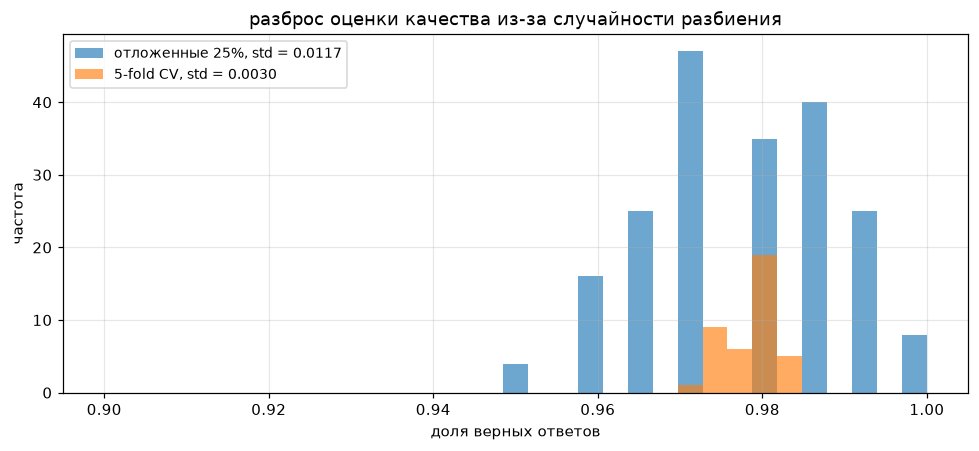

отложенная: 0.9774, размах 0.9510 .. 1.0000
5-fold CV : 0.9782, размах 0.9719 .. 0.9842


In [4]:
data_bc = load_breast_cancer()
X_bc, y_bc = data_bc.data, data_bc.target
pipe_bc = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))])

holdout = []
for s in range(200):
    Xa, Xb, ya, yb = train_test_split(X_bc, y_bc, test_size=0.25, random_state=s, stratify=y_bc)
    holdout.append(pipe_bc.fit(Xa, ya).score(Xb, yb))
holdout = np.asarray(holdout)

cv5 = np.array([
    cross_val_score(pipe_bc, X_bc, y_bc, cv=StratifiedKFold(5, shuffle=True, random_state=s)).mean()
    for s in range(40)
])

fig, ax = plt.subplots()
bins = np.linspace(0.90, 1.0, 34)
ax.hist(holdout, bins=bins, alpha=0.65, label=f"отложенные 25%, std = {holdout.std():.4f}")
ax.hist(cv5, bins=bins, alpha=0.65, label=f"5-fold CV, std = {cv5.std():.4f}")
ax.set_xlabel("доля верных ответов")
ax.set_ylabel("частота")
ax.set_title("разброс оценки качества из-за случайности разбиения")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"отложенная: {holdout.mean():.4f}, размах {holdout.min():.4f} .. {holdout.max():.4f}")
print(f"5-fold CV : {cv5.mean():.4f}, размах {cv5.min():.4f} .. {cv5.max():.4f}")

Одна и та же модель на одних и тех же данных даёт от 0.92 до 1.00 в зависимости от того, какое случайное число подставлено в `random_state`. Размах примерно 8 процентных пунктов.

Отсюда практическое следствие, которое игнорируют чаще всего: **сравнивать две модели по одному замеру на одном разбиении бессмысленно**, если разница между ними меньше разброса оценки. Кросс-валидация сокращает разброс примерно втрое, но не устраняет его. Смотреть надо не только на среднее, но и на разброс по фолдам.

## 2.3 Главное правило

> Любое решение, принятое на основании данных, является частью процедуры обучения и должно приниматься только по обучающей части фолда.

Под это правило попадает больше вещей, чем кажется:

* параметры масштабирования (среднее и стандартное отклонение);
* заполнение пропусков;
* **отбор признаков**;
* подбор гиперпараметров;
* порог классификации;
* кодирование категорий по целевой переменной (target encoding);
* удаление выбросов.

Нарушение называется утечкой (leakage) и даёт оптимистично смещённую оценку. Коварство в том, что смещение не выглядит подозрительным: утечка редко даёт идеальные 100%, она даёт правдоподобные цифры, которые невозможно опровергнуть, не переделав эксперимент.

Продемонстрируем на предельном случае. Сгенерируем данные, в которых сигнала нет вообще: 100 объектов, 3000 признаков из стандартного нормального распределения, метки классов подброшены монеткой независимо от признаков. Единственная честная оценка ROC AUC здесь 0.5. Отберём 20 лучших признаков по корреляции с целевой переменной на всех данных, а затем честно измерим качество кросс-валидацией.

In [5]:
rng = np.random.default_rng(0)
n_obj, n_feat = 100, 3000
X_noise = rng.normal(size=(n_obj, n_feat))
y_noise = rng.integers(0, 2, size=n_obj)

cv_leak = StratifiedKFold(5, shuffle=True, random_state=SEED)
clf = LogisticRegression(max_iter=5000)

corr = np.abs((X_noise - X_noise.mean(0)).T @ (y_noise - y_noise.mean())) / (
    n_obj * X_noise.std(0) * y_noise.std())
top20 = np.argsort(corr)[-20:]

wrong = cross_val_score(clf, X_noise[:, top20], y_noise, cv=cv_leak, scoring="roc_auc")
right = cross_val_score(
    Pipeline([("sel", SelectKBest(f_classif, k=20)), ("clf", clf)]),
    X_noise, y_noise, cv=cv_leak, scoring="roc_auc")

print(f"максимальная выборочная |корреляция| среди {n_feat} шумовых признаков: {corr.max():.3f}")
print()
print(f"отбор ДО кросс-валидации      ROC AUC = {wrong.mean():.3f}   по фолдам {np.round(wrong, 2)}")
print(f"отбор ВНУТРИ кросс-валидации  ROC AUC = {right.mean():.3f}   по фолдам {np.round(right, 2)}")
print()
print("истинное значение равно 0.500: связи между признаками и целевой переменной нет")

максимальная выборочная |корреляция| среди 3000 шумовых признаков: 0.343

отбор ДО кросс-валидации      ROC AUC = 0.961   по фолдам [0.94 0.95 0.97 0.98 0.97]
отбор ВНУТРИ кросс-валидации  ROC AUC = 0.358   по фолдам [0.39 0.3  0.45 0.52 0.13]

истинное значение равно 0.500: связи между признаками и целевой переменной нет


### Разбор

Данные не содержат сигнала, но неправильная схема уверенно показывает качество заметно выше случайного.

Механизм такой. При 3000 независимых признаках и 100 объектах максимум выборочной корреляции по чистой случайности достигает 0.35 и выше: это порядковая статистика, а не сигнал. Отбор находит именно те признаки, которым повезло на **этой** выборке. Дальше кросс-валидация уже не способна это обнаружить, потому что каждый тестовый фолд участвовал в отборе: признаки подогнаны в том числе под него.

Формально: кросс-валидация оценивает только последний шаг конвейера, обучение логистической регрессии на 20 готовых признаках. Она ничего не знает о том, что этим двадцати предшествовал перебор трёх тысяч. Оценивать нужно процедуру целиком.

Правильная схема прогоняет через фолд весь конвейер, включая отбор. `Pipeline` делает это автоматически: при каждом вызове `fit` он обучает все шаги только на обучающей части, а на тестовой лишь применяет уже настроенные преобразования. Отсюда правило: **всё, что настраивается по данным, должно быть шагом Pipeline, а не выполняться заранее над всей таблицей.**

Масштаб смещения зависит от отношения числа признаков к числу объектов. При 3000 признаках и 100 объектах эффект драматичен, при 20 признаках и 100 тысячах объектов почти незаметен. Но заранее знать, в каком вы режиме, нельзя, поэтому правило соблюдают всегда.

## 2.4 Вложенная кросс-валидация

Есть второй, более тонкий источник того же смещения. Пусть гиперпараметры подобраны кросс-валидацией, и мы берём лучший достигнутый результат как оценку качества. Это снова оптимистичная оценка: перебрав 50 конфигураций, мы выбрали ту, которой повезло на конкретном разбиении, а максимум из 50 шумных величин смещён вверх относительно их истинных значений.

Вложенная схема разделяет две разные задачи:

* **внутренний цикл** выбирает модель или гиперпараметры;
* **внешний цикл** оценивает качество процедуры целиком, включая внутренний выбор.

Оценка внешнего цикла отвечает на вопрос "какое качество даст эта процедура, применённая к новым данным", а не "какое качество показала лучшая из перебранных конфигураций".

Стоимость: $K_{\text{внеш}} \times K_{\text{внутр}} \times |\text{сетка}|$ обучений.

Когда это нужно: для честной цифры в отчёте и для сравнения принципиально разных подходов между собой. Для финального обучения продакшн-модели вложенность не нужна, гиперпараметры подбирают обычной кросс-валидацией на всех доступных данных.

In [6]:
X_syn, y_syn = make_classification(n_samples=300, n_features=60, n_informative=5, n_redundant=5,
                                   flip_y=0.05, class_sep=0.8, random_state=SEED)

base = Pipeline([("sc", StandardScaler()),
                 ("sel", SelectKBest(f_classif)),
                 ("clf", LogisticRegression(max_iter=5000))])
grid = {"sel__k": [5, 10, 20, 40, 60], "clf__C": [0.01, 0.1, 1.0, 10.0]}

inner = StratifiedKFold(5, shuffle=True, random_state=1)
outer = StratifiedKFold(5, shuffle=True, random_state=2)

search = GridSearchCV(base, grid, scoring="roc_auc", cv=inner).fit(X_syn, y_syn)
nested = cross_val_score(GridSearchCV(base, grid, scoring="roc_auc", cv=inner),
                         X_syn, y_syn, cv=outer, scoring="roc_auc")

print(f"лучший результат внутренней CV : {search.best_score_:.4f}   {search.best_params_}")
print(f"вложенная CV, честная оценка   : {nested.mean():.4f} +- {nested.std():.4f}")
print(f"смещение от выбора по сетке    : {search.best_score_ - nested.mean():+.4f}")

лучший результат внутренней CV : 0.8347   {'clf__C': 10.0, 'sel__k': 5}
вложенная CV, честная оценка   : 0.8294 +- 0.0302
смещение от выбора по сетке    : +0.0053


Смещение здесь скромное, порядка одного пункта, потому что сетка маленькая (20 конфигураций) и сигнал в данных реальный. Оно растёт с размером сетки и падает с размером выборки. При переборе сотен конфигураций на нескольких сотнях объектов разрыв легко достигает нескольких пунктов, и именно он объясняет классическую ситуацию, когда модель на продакшене работает хуже, чем обещал отчёт.

# Часть III. Линейная регрессия и отбор признаков

## 3.1 Модель

$$\hat y = \beta_0 + \sum_{j=1}^{p}\beta_j x_j, \qquad \hat\beta = \arg\min_\beta \|y - X\beta\|_2^2 = (X^\top X)^{-1}X^\top y$$

При выполнении условий Гаусса-Маркова (некоррелированные остатки с постоянной дисперсией, отсутствие точной коллинеарности) МНК даёт оценку с наименьшей дисперсией среди линейных **несмещённых** оценок. Последнее слово принципиально: смещённые оценки вроде Ridge и Lasso могут иметь меньшую среднеквадратичную ошибку за счёт заметно меньшей дисперсии, и на реальных данных обычно её и имеют. Оптимальность МНК это оптимальность внутри узкого класса, а не вообще.

## 3.2 Метрики регрессии

| Метрика | Формула | Свойства |
|---|---|---|
| MSE | $\frac1n\sum (y_i-\hat y_i)^2$ | Единицы измерения в квадрате, чувствительна к выбросам, гладкая |
| RMSE | $\sqrt{\text{MSE}}$ | В единицах целевой переменной, интерпретируема |
| MAE | $\frac1n\sum \lvert y_i-\hat y_i\rvert$ | Устойчива к выбросам, её оптимум это медиана, а не среднее |
| MAPE | $\frac{100}{n}\sum \lvert (y_i-\hat y_i)/y_i\rvert$ | Относительная, не определена при $y_i=0$, штрафует завышение слабее занижения |
| $R^2$ | $1 - \frac{\sum (y_i-\hat y_i)^2}{\sum (y_i-\bar y)^2}$ | Доля объяснённой дисперсии, сравнение с предсказанием средним |

Про $R^2$ надо помнить два факта. На обучающей выборке он не убывает при добавлении **любого** признака, поэтому по нему нельзя сравнивать модели разной размерности. На тестовой выборке он может быть отрицательным: это значит, что модель хуже константы.

Выбор между MSE и MAE это не вопрос вкуса, а вопрос того, как стоимость ошибки растёт с её величиной. Если ошибка в 10 единиц ровно в десять раз хуже ошибки в 1 единицу, нужна MAE. Если в сто раз хуже, нужна MSE. Метрика выбирается из задачи и фиксируется **до** экспериментов, иначе появляется соблазн выбрать ту, по которой выигрывает уже полученный результат.

### Информационные критерии

Для линейных моделей есть альтернатива кросс-валидации: штрафовать правдоподобие за число параметров.

$$\mathrm{AIC} = n\ln\hat\sigma^2 + 2p, \qquad \mathrm{BIC} = n\ln\hat\sigma^2 + p\ln n$$

BIC штрафует сильнее при $n > e^2 \approx 7.4$ и выбирает более экономные модели. AIC асимптотически оптимален по качеству предсказания, BIC состоятелен по выбору истинной модели, если она вообще присутствует среди рассматриваемых. Оба требуют правильно специфицированной модели и разваливаются при $p$, сопоставимом с $n$. Кросс-валидация надёжнее, но дороже.

In [7]:
y_demo = np.array([10.0, 12.0, 14.0, 16.0, 18.0])
preds = {
    "константа (среднее)": np.full(5, 14.0),
    "хорошая модель": np.array([10.5, 11.8, 14.2, 15.5, 18.4]),
    "сдвиг на +5": np.array([15.0, 17.0, 19.0, 21.0, 23.0]),
    "точная, но один выброс": np.array([10.0, 12.0, 14.0, 16.0, 30.0]),
}

print(pd.DataFrame([
    {"предсказание": name,
     "MSE": mean_squared_error(y_demo, p),
     "RMSE": mean_squared_error(y_demo, p) ** 0.5,
     "MAE": mean_absolute_error(y_demo, p),
     "R2": r2_score(y_demo, p)}
    for name, p in preds.items()
]).to_string(index=False))

          предсказание    MSE  RMSE  MAE     R2
   константа (среднее)  8.000 2.828 2.40  0.000
        хорошая модель  0.148 0.385 0.36  0.982
           сдвиг на +5 25.000 5.000 5.00 -2.125
точная, но один выброс 28.800 5.367 2.40 -2.600


Последние две строки показывают разницу между MSE и MAE. Модель со сдвигом ошибается на 5 единиц в каждой из пяти точек, модель с выбросом идеальна в четырёх точках и ошибается на 12 в одной. По MAE первая хуже (5.0 против 2.4), по RMSE вторая хуже (5.37 против 5.0). Какая из них хуже на самом деле, зависит исключительно от того, что стоит ошибка в вашей задаче.

Строка с константой даёт $R^2 = 0$ по определению: это точка отсчёта. Модель со сдвигом даёт отрицательный $R^2$, то есть она хуже, чем не иметь модели вообще.

## 3.3 Данные для экспериментов

Возьмём синтетические данные, где точно известно, какие признаки несут сигнал: 300 объектов, 40 признаков, из них 6 информативных. К трём информативным добавим почти точные копии, чтобы воспроизвести мультиколлинеарность, которая в реальных данных встречается постоянно.

In [8]:
X_base, y_reg, coef_true = make_regression(n_samples=300, n_features=40, n_informative=6,
                                           noise=15.0, coef=True, random_state=SEED)
informative = np.flatnonzero(coef_true)

rng = np.random.default_rng(SEED)
dup = X_base[:, informative[:3]] + rng.normal(scale=0.25, size=(300, 3))
X_reg = np.hstack([X_base, dup])

names_reg = [f"f{j:02d}" for j in range(40)] + [f"dup_f{j:02d}" for j in informative[:3]]
X_reg_df = pd.DataFrame(X_reg, columns=names_reg)

is_signal = np.zeros(len(names_reg), dtype=bool)
is_signal[informative] = True
is_signal[40:] = True

print(f"объектов {X_reg.shape[0]}, признаков {X_reg.shape[1]}, из них несут сигнал {is_signal.sum()}")
print(f"информативные: {[names_reg[j] for j in informative]}")
print(f"истинные коэффициенты: {coef_true[informative].round(1)}")
print(f"std шума при генерации: 15.0, std целевой переменной: {y_reg.std():.1f}")

объектов 300, признаков 43, из них несут сигнал 9
информативные: ['f00', 'f07', 'f12', 'f25', 'f27', 'f31']
истинные коэффициенты: [57.8 43.9 37.6  1.7 99.4 54.4]
std шума при генерации: 15.0, std целевой переменной: 136.3


In [9]:
cv_reg = KFold(5, shuffle=True, random_state=SEED)
ols = Pipeline([("sc", StandardScaler()), ("m", LinearRegression())])

sc = cross_validate(ols, X_reg_df, y_reg, cv=cv_reg, return_train_score=True,
                    scoring=["r2", "neg_root_mean_squared_error"])

print(f"R2 на обучении : {sc['train_r2'].mean():.4f}")
print(f"R2 на тесте    : {sc['test_r2'].mean():.4f} +- {sc['test_r2'].std():.4f}")
print(f"RMSE на тесте  : {-sc['test_neg_root_mean_squared_error'].mean():.2f}")
print(f"предел RMSE, заданный шумом: 15.00")

R2 на обучении : 0.9910
R2 на тесте    : 0.9851 +- 0.0034
RMSE на тесте  : 16.38
предел RMSE, заданный шумом: 15.00


Базовая модель на всех 43 признаках уже работает неплохо, разрыв между обучением и тестом около 2 пунктов $R^2$. Дальше задача не столько поднять качество (потолок задан шумом), сколько получить компактную модель, которая не хуже, и понять, какие методы находят настоящие признаки, а какие нет.

## 3.4 Фильтры

Фильтр ранжирует признаки по статистике, вычисленной **независимо от модели**, и берёт лучшие $k$.

**F-тест и корреляция Пирсона.** `f_regression` вычисляет

$$F_j = \frac{r_j^2}{1-r_j^2}(n-2), \qquad r_j = \mathrm{corr}(x_j, y)$$

Это строго монотонная функция от $\lvert r_j \rvert$, поэтому ранжирование по F-тесту и по модулю корреляции идентичны. Улавливает только линейную связь.

**Взаимная информация.**

$$I(X;Y) = \iint p(x,y)\,\ln\frac{p(x,y)}{p(x)p(y)}\,dx\,dy$$

Равна нулю тогда и только тогда, когда переменные независимы, поэтому улавливает любую зависимость, включая немонотонную. Оценивается непараметрически по расстояниям до ближайших соседей: оценка шумная на малых выборках и зависит от параметра `n_neighbors`. Для линейной модели её преимущество перед корреляцией сомнительно, потому что сама модель всё равно линейна: признак с сильной нелинейной связью будет отобран, но использовать её линейная регрессия не сможет.

**Порог дисперсии.** `VarianceThreshold` убирает константы и почти константы. Единственный фильтр, не использующий $y$, поэтому безвреден с точки зрения утечки, но и малополезен.

Свойства фильтров:

* Дёшевы: одна проходка по данным, стоимость линейна по числу признаков. При десятках тысяч признаков это единственный вариант для первого прохода.
* Не зависят от модели, поэтому оптимизируют не то, что оптимизирует модель.
* **Оценивают каждый признак изолированно.** Отсюда два системных дефекта, которые разберём отдельно: фильтр не видит полезности признака в комбинации с другими и не убирает дублирующие друг друга признаки.

In [10]:
Xs_reg = StandardScaler().fit_transform(X_reg_df)

f_stat, p_val = f_regression(Xs_reg, y_reg)
mi = mutual_info_regression(Xs_reg, y_reg, random_state=SEED)
pearson = np.abs((Xs_reg.T @ (y_reg - y_reg.mean())) / (len(y_reg) * y_reg.std()))

rank = pd.DataFrame({"признак": names_reg, "|corr|": pearson, "F": f_stat,
                     "MI": mi, "несёт сигнал": is_signal})
rank["ранг F"] = rank["F"].rank(ascending=False).astype(int)
rank["ранг MI"] = rank["MI"].rank(ascending=False).astype(int)

print(rank.sort_values("F", ascending=False).head(12).to_string(index=False))
print()
print("сколько настоящих признаков попало в top-9 по каждому критерию:")
print(f"  F-тест              : {is_signal[np.argsort(-f_stat)[:9]].sum()} из 9")
print(f"  взаимная информация : {is_signal[np.argsort(-mi)[:9]].sum()} из 9")

признак  |corr|       F    MI  несёт сигнал  ранг F  ранг MI
    f27   0.702 289.507 0.352          True       1        1
dup_f07   0.396  55.288 0.114          True       2        3
    f00   0.387  52.638 0.085          True       3        5
dup_f00   0.384  51.614 0.075          True       4        6
    f07   0.381  50.477 0.158          True       5        2
    f31   0.364  45.645 0.031          True       6       15
    f12   0.247  19.339 0.051          True       7        9
dup_f12   0.238  17.971 0.046          True       8       11
    f08   0.139   5.903 0.016         False       9       22
    f29   0.133   5.406 0.025         False      10       17
    f39   0.089   2.355 0.068         False      11        7
    f26   0.079   1.866 0.014         False      12       23

сколько настоящих признаков попало в top-9 по каждому критерию:
  F-тест              : 8 из 9
  взаимная информация : 6 из 9


На этих данных фильтр справляется: все 9 признаков с сигналом (6 информативных плюс 3 дубликата) занимают верхние строчки, и оба критерия согласованы.

Но обратите внимание на структуру отобранного: `f00` и `dup_f00` стоят рядом с почти одинаковыми значениями F. Фильтр честно взял оба, хотя второй не добавляет ни бита информации к первому. Если бы бюджет был 5 признаков, три места из пяти ушли бы на дубликаты, и два настоящих информативных признака остались бы за бортом. Это первый системный дефект фильтров: **они не знают о взаимной избыточности отобранного**.

### Когда фильтр ломается полностью

Второй дефект тяжелее. Построим данные, где признак полезен только в паре с другим.

Пусть $u$ это скрытый фактор с большой дисперсией, а $s_1 = u + a$ и $s_2 = u + b$ это два зашумлённых измерения. Целевая переменная зависит от разности: $y = s_1 - s_2 = a - b$. Общий фактор $u$ полностью сокращается.

По отдельности каждый из $s_1, s_2$ почти не коррелирует с $y$: их дисперсия определяется главным образом фактором $u$, которого в $y$ нет. Считая точно, $\mathrm{corr}(y, s_1) = 1/\sqrt{20} \approx 0.22$. Вместе они объясняют $y$ полностью.

Добавим шесть признаков-обманок, каждая из которых коррелирует с $y$ на уровне 0.33, то есть **сильнее**, чем настоящие. Фильтр обязан предпочесть их.

In [11]:
rng = np.random.default_rng(11)
n = 600
u = rng.normal(scale=3.0, size=n)
s1 = u + rng.normal(size=n)
s2 = u + rng.normal(size=n)
y_s = s1 - s2 + rng.normal(scale=0.2, size=n)

weak = 0.35 * (y_s / y_s.std())[:, None] + rng.normal(size=(n, 6))
X_s = np.column_stack([s1, s2, weak])
names_s = ["s1", "s2"] + [f"w{k}" for k in range(6)]

corr_s = np.abs(np.array([np.corrcoef(X_s[:, j], y_s)[0, 1] for j in range(X_s.shape[1])]))
print(pd.DataFrame({"признак": names_s, "|corr| с y": corr_s.round(3)}).to_string(index=False))

cvs = KFold(5, shuffle=True, random_state=SEED)
r2_of = lambda cols: cross_val_score(LinearRegression(), X_s[:, cols], y_s, cv=cvs, scoring="r2").mean()

top2 = np.argsort(corr_s)[-2:]
Xs_s = StandardScaler().fit_transform(X_s)

print()
print(f"фильтр берёт top-2 по корреляции {[names_s[j] for j in top2]:}: R2 = {r2_of(top2):.3f}")
print(f"настоящая пара ['s1', 's2']              : R2 = {r2_of([0, 1]):.3f}")
print()
print("что находят методы, учитывающие признаки совместно:")
rfe_s = RFE(LinearRegression(), n_features_to_select=2).fit(Xs_s, y_s)
las_s = Lasso(alpha=0.05).fit(Xs_s, y_s)
print(f"  RFE  : {[names_s[j] for j in np.flatnonzero(rfe_s.support_)]}")
print(f"  Lasso: {[names_s[j] for j in np.flatnonzero(np.abs(las_s.coef_) > 1e-6)]}")

признак  |corr| с y
     s1       0.231
     s2       0.255
     w0       0.381
     w1       0.330
     w2       0.320
     w3       0.266
     w4       0.265
     w5       0.289

фильтр берёт top-2 по корреляции ['w1', 'w0']: R2 = 0.207
настоящая пара ['s1', 's2']              : R2 = 0.982

что находят методы, учитывающие признаки совместно:
  RFE  : ['s1', 's2']
  Lasso: ['s1', 's2', 'w0', 'w1', 'w2', 'w3', 'w4', 'w5']


Фильтр выбирает два признака с наибольшей корреляцией и получает $R^2$ около 0.2. Настоящая пара даёт около 0.99. Разница в пять раз, и никакое увеличение бюджета фильтра эту ситуацию не чинит по существу: критерий ранжирования просто не содержит информации о совместном поведении признаков.

RFE и Lasso находят правильную пару, потому что оценивают признаки в контексте модели, где уже присутствуют остальные.

Такая конфигурация называется эффектом подавления (suppressor variable) и встречается в реальных данных чаще, чем принято думать: везде, где полезна разность или отношение двух измерений, а не сами измерения. Разность цены и себестоимости, разница между двумя датчиками, изменение показателя относительно предыдущего периода.

**Вывод:** фильтр это инструмент грубого предварительного отсева, когда признаков десятки тысяч и ничего дороже не запускается. Как основной механизм отбора он ненадёжен.

## 3.5 Обёртки

Обёртка перебирает подмножества признаков и оценивает каждое качеством конкретной модели на кросс-валидации. Полный перебор невозможен: подмножеств $2^p$, для $p=43$ это порядка $10^{13}$. Используются жадные стратегии.

**Последовательное добавление (forward selection).** Начинаем с пустого множества, на каждом шаге добавляем признак, дающий максимальный прирост качества. Стоимость $O(p^2)$ обучений. Не умеет исправлять раннюю ошибку: добавленный первым признак остаётся навсегда, даже если в компании других он оказался лишним.

**Последовательное удаление (backward elimination).** Начинаем со всех признаков, на каждом шаге убираем наименее полезный. Требует обучаемости полной модели, то есть $p < n$. Лучше улавливает эффекты, проявляющиеся только в группе: на ранних шагах каждый признак оценивается в присутствии всех остальных, поэтому пара вроде $s_1, s_2$ из предыдущего примера не будет разрушена.

**RFE (recursive feature elimination).** Удешевлённое удаление: вместо переобучения модели без каждого кандидата используется внутренняя мера важности (модуль коэффициента для линейных моделей). На каждом шаге отбрасываются наименее важные, модель переобучается. Стоимость $O(p)$ обучений вместо $O(p^2)$.

Критично: RFE по модулю коэффициента **требует масштабирования**. Без него величина коэффициента отражает единицы измерения признака, а не его важность, и первым выбросится признак, измеренный в километрах вместо метров.

Свойства обёрток:

* Оптимизируют ровно ту метрику и ту модель, которые нужны.
* Учитывают взаимодействия, убирают дубликаты.
* Дороги: сотни и тысячи обучений.
* **Переобучаются под процедуру отбора.** Число рассмотренных подмножеств велико, и качество лучшего из них смещено вверх ровно по той же причине, что и в разделе 2.4. Поэтому число признаков, выбранное через `RFECV`, нельзя одновременно использовать как оценку качества: нужна внешняя петля.

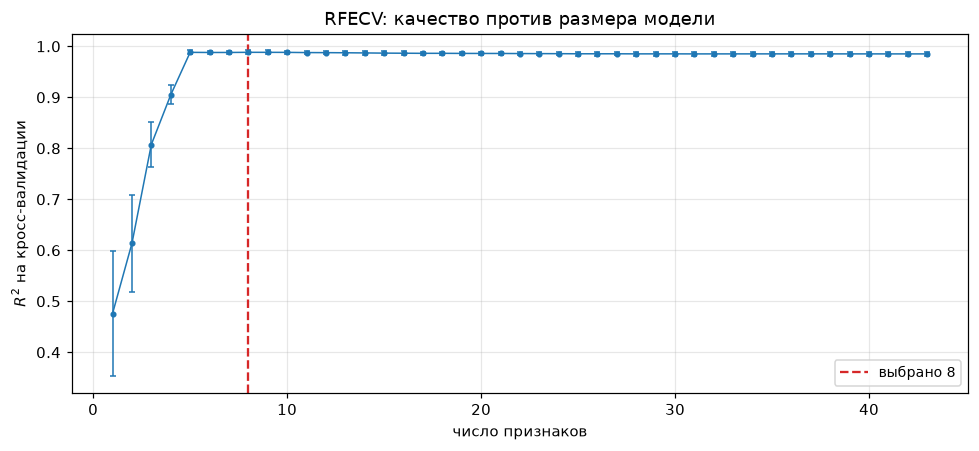

RFECV оставил 8: ['f00', 'f07', 'f12', 'f27', 'f31', 'dup_f00', 'dup_f07', 'dup_f12']
из них с настоящим сигналом: 8


In [12]:
rfecv = RFECV(LinearRegression(), step=1, cv=cv_reg, scoring="r2",
              min_features_to_select=1).fit(Xs_reg, y_reg)

k_axis = np.arange(1, len(rfecv.cv_results_["mean_test_score"]) + 1)
fig, ax = plt.subplots()
ax.errorbar(k_axis, rfecv.cv_results_["mean_test_score"],
            yerr=rfecv.cv_results_["std_test_score"], fmt="o-", ms=3, lw=1, capsize=2)
ax.axvline(rfecv.n_features_, color="C3", ls="--", label=f"выбрано {rfecv.n_features_}")
ax.set_xlabel("число признаков")
ax.set_ylabel("$R^2$ на кросс-валидации")
ax.set_title("RFECV: качество против размера модели")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

chosen = [names_reg[j] for j in np.flatnonzero(rfecv.support_)]
print(f"RFECV оставил {rfecv.n_features_}: {chosen}")
print(f"из них с настоящим сигналом: {is_signal[rfecv.support_].sum()}")

In [13]:
fwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=8, direction="forward",
                                cv=cv_reg, scoring="r2").fit(Xs_reg, y_reg)
bwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=8, direction="backward",
                                cv=cv_reg, scoring="r2").fit(Xs_reg, y_reg)

sel_fwd = sorted(names_reg[j] for j in np.flatnonzero(fwd.get_support()))
sel_bwd = sorted(names_reg[j] for j in np.flatnonzero(bwd.get_support()))

print(f"вперёд : {sel_fwd}")
print(f"назад  : {sel_bwd}")
print(f"совпало: {sorted(set(sel_fwd) & set(sel_bwd))}")

вперёд : ['f00', 'f05', 'f07', 'f12', 'f25', 'f27', 'f31', 'f33']
назад  : ['f00', 'f05', 'f07', 'f12', 'f25', 'f27', 'f31', 'f33']
совпало: ['f00', 'f05', 'f07', 'f12', 'f25', 'f27', 'f31', 'f33']


Кривая RFECV выходит на плато: после примерно девяти признаков качество перестаёт расти. Плоское плато это типичная картина, и выбор точки максимума на нём во многом случаен, потому что различия внутри плато меньше, чем усы погрешности. Практичнее выбирать не максимум, а левый край плато, то есть наименьшую модель, качество которой лежит в пределах одной стандартной ошибки от максимума. Это правило одной стандартной ошибки, и оно даёт заметно более устойчивый результат.

Прямой и обратный проходы дают пересекающиеся, но не совпадающие наборы. Это нормально: обе стратегии жадные и решают невыпуклую комбинаторную задачу, их результат зависит от порядка шагов. Расхождение между ними полезно как индикатор: если два разумных метода выбирают разные наборы, значит выбор плохо определён данными.

## 3.6 Встроенные методы: регуляризация

Вместо перебора подмножеств добавим к функции потерь штраф за величину коэффициентов. Отбор станет побочным продуктом обучения.

### Ridge (L2)

$$\hat\beta^{\text{ridge}} = \arg\min_\beta\left\{\|y-X\beta\|_2^2 + \alpha\|\beta\|_2^2\right\} = (X^\top X + \alpha I)^{-1}X^\top y$$

Добавление $\alpha I$ к диагонали делает матрицу обратимой **всегда**, включая случай $p>n$. Это прямое лекарство от мультиколлинеарности из раздела 1.3.

Что именно происходит, видно через сингулярное разложение $X = UDV^\top$:

$$\hat y^{\text{ridge}} = \sum_{j} u_j\,\frac{d_j^2}{d_j^2+\alpha}\,u_j^\top y$$

Каждая главная компонента сжимается с коэффициентом $d_j^2/(d_j^2+\alpha)$. Компоненты с большой дисперсией ($d_j$ велико) почти не трогаются, компоненты с малой дисперсией подавляются сильно. А именно направления с малой дисперсией и дают взрыв дисперсии коэффициентов. Ridge гасит их прицельно.

При $\alpha=0$ это МНК, при $\alpha\to\infty$ все коэффициенты стремятся к нулю, но **ни один не становится нулём точно**. Ridge не отбирает признаки, он их взвешивает.

### Lasso (L1)

$$\hat\beta^{\text{lasso}} = \arg\min_\beta\left\{\|y-X\beta\|_2^2 + \alpha\|\beta\|_1\right\}$$

Закрытой формы нет, задача решается координатным спуском. Принципиальное отличие: часть коэффициентов обращается в **точный** ноль, то есть Lasso выполняет отбор признаков как часть обучения.

Почему L1 даёт нули. Эквивалентная формулировка через ограничение: минимизировать $\|y-X\beta\|^2$ при $\|\beta\|_1 \le t$. Область ограничения для L1 это ромб с вершинами на осях координат, для L2 это круг. Линии уровня функции потерь это эллипсы с центром в решении МНК. Оптимум лежит в точке касания эллипса и области. У ромба есть углы, и они лежат на осях, где часть координат равна нулю. Касание в углу происходит с ненулевой вероятностью, у круга углов нет.

Для ортогонального дизайна решение выписывается явно и разница видна алгебраически:

$$\hat\beta_j^{\text{lasso}} = \mathrm{sign}(\hat\beta_j^{\text{МНК}})\big(|\hat\beta_j^{\text{МНК}}| - \alpha/2\big)_+, \qquad \hat\beta_j^{\text{ridge}} = \frac{\hat\beta_j^{\text{МНК}}}{1+\alpha}$$

Lasso вычитает константу и обрезает по нулю (мягкое пороговое преобразование), Ridge делит на константу. Вычитание достигает нуля, деление нет.

### ElasticNet

$$\arg\min_\beta\left\{\|y-X\beta\|_2^2 + \alpha\Big(\rho\|\beta\|_1 + \tfrac{1-\rho}{2}\|\beta\|_2^2\Big)\right\}$$

Компромисс, решающий две конкретные проблемы чистого Lasso. Первая: при $p>n$ Lasso не может выбрать больше $n$ признаков. Вторая: в группе сильно коррелированных признаков Lasso выбирает одного представителя произвольно, а L2-составляющая заставляет такую группу входить в модель целиком с близкими коэффициентами.

### Масштабирование обязательно

Штраф $\sum\beta_j^2$ или $\sum|\beta_j|$ складывает коэффициенты разных признаков в одну сумму. Коэффициент при признаке в метрах и при том же признаке в километрах отличаются в тысячу раз, и штраф этого не знает. Без стандартизации регуляризация давит признаки тем сильнее, чем мельче их единицы измерения. Это не тонкость, это ошибка, полностью меняющая результат отбора.

Свободный член $\beta_0$ не штрафуется никогда: иначе модель зависела бы от сдвига начала отсчёта целевой переменной. sklearn это учитывает автоматически.

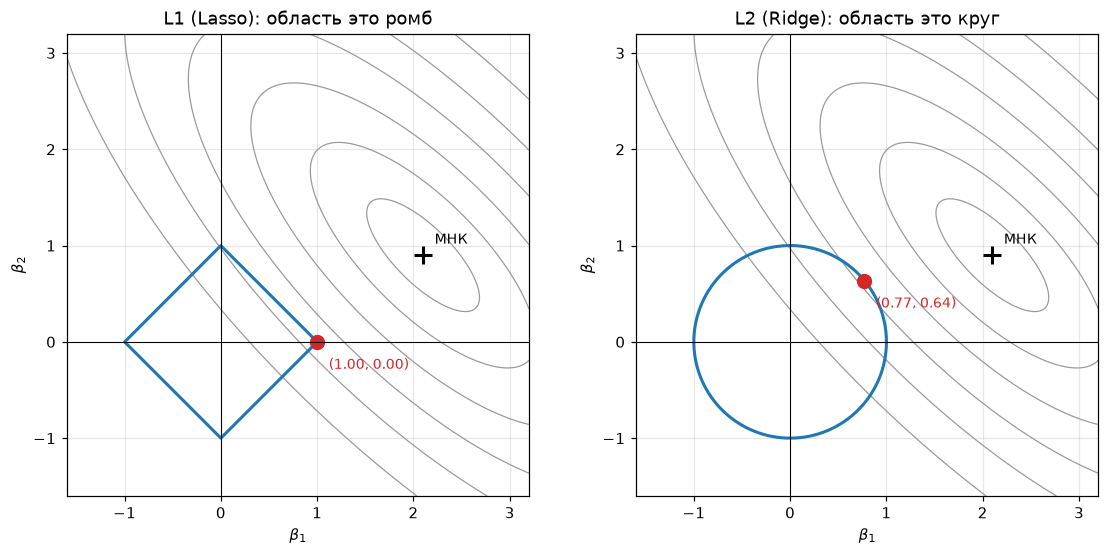

In [14]:
b1 = np.linspace(-1.6, 3.2, 400)
b2 = np.linspace(-1.6, 3.2, 400)
B1, B2 = np.meshgrid(b1, b2)
beta_ols = np.array([2.1, 0.9])
A = np.array([[1.0, 0.75], [0.75, 1.0]])
D1, D2 = B1 - beta_ols[0], B2 - beta_ols[1]
Z = A[0, 0] * D1**2 + 2 * A[0, 1] * D1 * D2 + A[1, 1] * D2**2

t = 1.0
th = np.linspace(0, 2 * np.pi, 4000)
dirs = np.column_stack([np.cos(th), np.sin(th)])
boundaries = {
    "L1 (Lasso): область это ромб": t * dirs / np.abs(dirs).sum(1, keepdims=True),
    "L2 (Ridge): область это круг": t * dirs,
}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5))
for ax, (title, pts) in zip(axes, boundaries.items()):
    ax.contour(B1, B2, Z, levels=[0.15, 0.6, 1.4, 2.6, 4.2, 6.5], colors="0.6", linewidths=0.8)
    ax.plot(pts[:, 0], pts[:, 1], color="C0", lw=2)
    q = A[0, 0] * (pts[:, 0] - beta_ols[0])**2 + \
        2 * A[0, 1] * (pts[:, 0] - beta_ols[0]) * (pts[:, 1] - beta_ols[1]) + \
        A[1, 1] * (pts[:, 1] - beta_ols[1])**2
    hit = pts[np.argmin(q)]
    ax.plot(*beta_ols, "k+", ms=12, mew=2)
    ax.annotate("МНК", beta_ols + 0.12, fontsize=9)
    ax.plot(*hit, "o", color="C3", ms=9)
    ax.annotate(f"({hit[0]:.2f}, {hit[1]:.2f})", hit + np.array([0.12, -0.28]), fontsize=9, color="C3")
    ax.axhline(0, color="k", lw=0.7)
    ax.axvline(0, color="k", lw=0.7)
    ax.set_title(title)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Слева оптимум попал ровно в вершину ромба, и второй коэффициент обратился в точный ноль. Справа точка касания круга лежит в общем положении, оба коэффициента ненулевые. Это вся геометрия разреженности L1 в одной картинке.

Теперь построим пути регуляризации на наших данных: как меняются все 43 коэффициента при изменении силы штрафа. Красным выделены признаки с настоящим сигналом, серым шум.

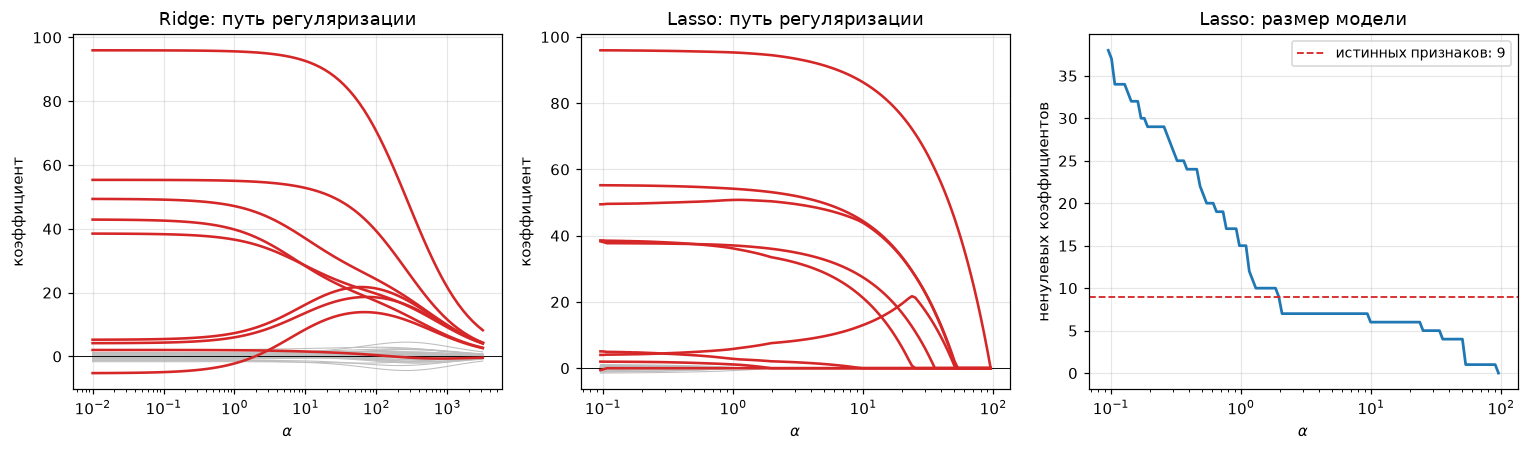

In [15]:
alphas_r = np.logspace(-2, 3.5, 80)
coefs_r = np.array([Ridge(alpha=a).fit(Xs_reg, y_reg).coef_ for a in alphas_r])
alphas_l, coefs_l, _ = lasso_path(Xs_reg, y_reg, n_alphas=120)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for j in range(Xs_reg.shape[1]):
    style = dict(color="C3", lw=1.7, zorder=3) if is_signal[j] else dict(color="0.75", lw=0.7, zorder=1)
    axes[0].plot(alphas_r, coefs_r[:, j], **style)
    axes[1].plot(alphas_l, coefs_l[j], **style)

for ax, title in zip(axes[:2], ["Ridge", "Lasso"]):
    ax.set_xscale("log")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("коэффициент")
    ax.set_title(f"{title}: путь регуляризации")

nnz = (np.abs(coefs_l) > 1e-9).sum(axis=0)
axes[2].plot(alphas_l, nnz, lw=1.8)
axes[2].axhline(is_signal.sum(), color="C3", ls="--", lw=1.2, label=f"истинных признаков: {is_signal.sum()}")
axes[2].set_xscale("log")
axes[2].set_xlabel(r"$\alpha$")
axes[2].set_ylabel("ненулевых коэффициентов")
axes[2].set_title("Lasso: размер модели")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

Различие видно сразу. У Ridge все 43 линии плавно сходятся к нулю, но ни одна его не достигает: модель всегда содержит все признаки. У Lasso линии обрываются в ноль по одной, и красные линии (настоящий сигнал) держатся дольше всех: последними из модели уходят именно они.

Правый график показывает, сколько признаков остаётся в модели. При большом $\alpha$ модель пуста, при малом содержит всё. Область около горизонтальной линии это диапазон $\alpha$, где размер модели совпадает с истинным.

Важная деталь: Lasso начинает включать шумовые признаки раньше, чем включил все настоящие. Идеального разделения не бывает, если сигнал сопоставим с шумом.

## 3.7 Подбор силы регуляризации

$\alpha$ это гиперпараметр, и подбирается он кросс-валидацией. Посмотрим на классическую картину компромисса смещения и разброса в явном виде.

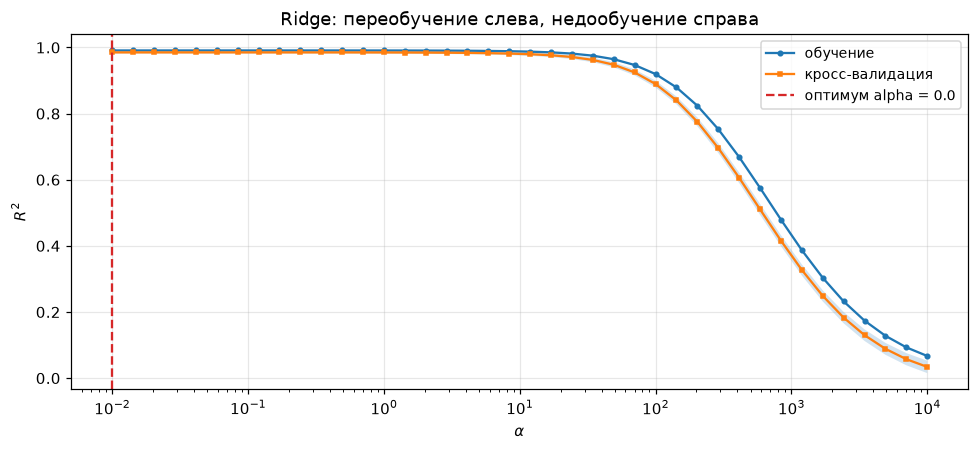

In [16]:
alpha_grid = np.logspace(-2, 4, 40)
tr_sc, te_sc = validation_curve(
    Pipeline([("sc", StandardScaler()), ("m", Ridge())]), X_reg_df, y_reg,
    param_name="m__alpha", param_range=alpha_grid, cv=cv_reg, scoring="r2")

fig, ax = plt.subplots()
ax.plot(alpha_grid, tr_sc.mean(1), "o-", ms=3, label="обучение")
ax.fill_between(alpha_grid, te_sc.mean(1) - te_sc.std(1), te_sc.mean(1) + te_sc.std(1), alpha=0.2)
ax.plot(alpha_grid, te_sc.mean(1), "s-", ms=3, label="кросс-валидация")
ax.axvline(alpha_grid[te_sc.mean(1).argmax()], color="C3", ls="--",
           label=f"оптимум alpha = {alpha_grid[te_sc.mean(1).argmax()]:.1f}")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("$R^2$")
ax.set_title("Ridge: переобучение слева, недообучение справа")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
las_cv = LassoCV(alphas=np.logspace(-2, 2.5, 80), cv=cv_reg, max_iter=50000).fit(Xs_reg, y_reg)
sel = np.flatnonzero(np.abs(las_cv.coef_) > 1e-8)

print(f"alpha* = {las_cv.alpha_:.3f}, ненулевых коэффициентов {len(sel)} из {len(names_reg)}")
print(f"из них с настоящим сигналом: {is_signal[sel].sum()} из {is_signal.sum()}")
print()
tbl = pd.DataFrame({"признак": [names_reg[j] for j in sel],
                    "коэффициент": las_cv.coef_[sel],
                    "сигнал": is_signal[sel]})
print(tbl.reindex(tbl["коэффициент"].abs().sort_values(ascending=False).index).to_string(index=False))

alpha* = 0.986, ненулевых коэффициентов 15 из 43
из них с настоящим сигналом: 8 из 9

признак  коэффициент  сигнал
    f27       95.308    True
    f31       54.195    True
    f00       50.645    True
    f12       37.067    True
    f07       36.494    True
dup_f07        5.486    True
dup_f00        2.986    True
    f25        1.155    True
    f33        0.957   False
    f08       -0.736   False
    f37        0.255   False
    f10        0.144   False
    f16        0.122   False
    f15       -0.118   False
    f29        0.113   False


Lasso с подобранным $\alpha$ оставляет больше признаков, чем настоящих. Это не дефект реализации, а известное свойство: $\alpha$, оптимальный по **качеству предсказания**, систематически меньше, чем $\alpha$, оптимальный по **восстановлению истинного набора признаков**. Кросс-валидация оптимизирует первое, и с точки зрения предсказания дешевле включить лишний признак с маленьким коэффициентом, чем потерять настоящий.

Отсюда практическое правило: если Lasso используется для отбора, а не для предсказания, разумно взять $\alpha$ больше оптимального по CV, либо применять правило одной стандартной ошибки, либо оценивать устойчивость отбора, чем мы сейчас и займёмся.

## 3.8 Устойчивость отбора

Раздел 1.3 показал, что среди коллинеарных признаков выбор представителя определяется случайностью выборки. Проверим это измеримо: 200 раз возьмём бутстрап-выборку, обучим Lasso с фиксированным $\alpha$ и посчитаем, как часто каждый признак попадает в модель.

Эта процедура называется отбором по устойчивости (stability selection). Её результат гораздо информативнее одного прогона: частота попадания говорит о том, насколько выбор признака подкреплён данными, а не удачей.

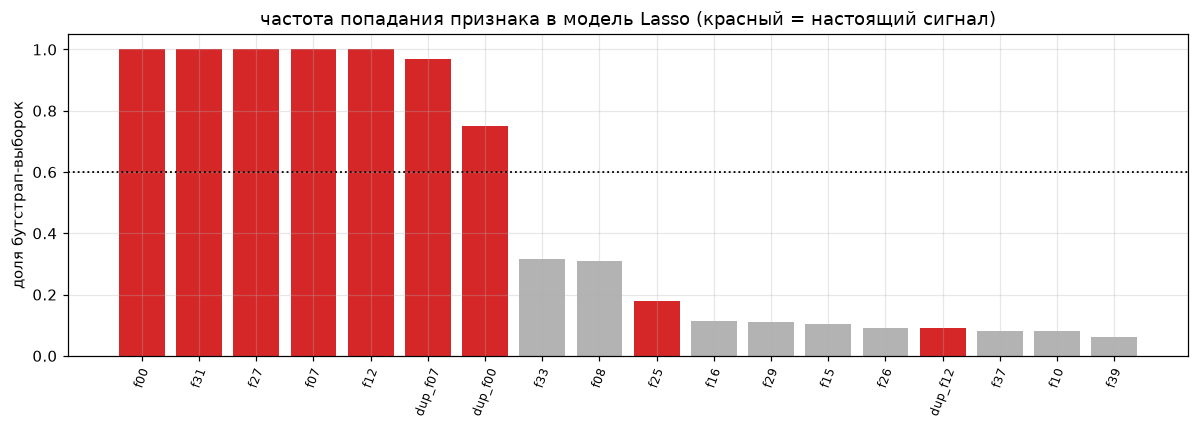

конкуренция внутри коллинеарных пар:
  f00: 1.00   dup_f00: 0.75   сумма: 1.75
  f07: 1.00   dup_f07: 0.97   сумма: 1.97
  f12: 1.00   dup_f12: 0.09   сумма: 1.09


In [18]:
rng = np.random.default_rng(SEED)
n_boot, n_obs = 200, Xs_reg.shape[0]
counts = np.zeros(Xs_reg.shape[1])

for _ in range(n_boot):
    idx = rng.integers(0, n_obs, n_obs)
    m = Lasso(alpha=las_cv.alpha_ * 2.5, max_iter=20000).fit(Xs_reg[idx], y_reg[idx])
    counts += np.abs(m.coef_) > 1e-8
freq = counts / n_boot

order = np.argsort(-freq)[:18]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(order)), freq[order],
       color=["C3" if is_signal[j] else "0.7" for j in order])
ax.axhline(0.6, color="k", ls=":", lw=1.2)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([names_reg[j] for j in order], rotation=70, fontsize=8)
ax.set_ylabel("доля бутстрап-выборок")
ax.set_title("частота попадания признака в модель Lasso (красный = настоящий сигнал)")
plt.tight_layout()
plt.show()

print("конкуренция внутри коллинеарных пар:")
for j in informative[:3]:
    d = names_reg.index(f"dup_f{j:02d}")
    print(f"  f{j:02d}: {freq[j]:.2f}   dup_f{j:02d}: {freq[d]:.2f}   сумма: {freq[j] + freq[d]:.2f}")

Внутри каждой коллинеарной пары частоты делятся: ни один из двух почти одинаковых признаков не попадает в модель стабильно, хотя вместе они присутствуют почти всегда. Один прогон Lasso показал бы один из них и создал впечатление определённости, которой в данных нет.

Практический вывод: если результат отбора идёт в отчёт или в решение о том, какие данные собирать дальше, одного прогона недостаточно. Частота попадания по бутстрапу это дешёвая и честная мера уверенности. Порог 0.6 отсекает признаки, чей отбор не воспроизводится.

## 3.9 Честное сравнение методов

Сравним все подходы в одинаковых условиях: внешняя 5-кратная кросс-валидация оценивает качество, внутренняя подбирает гиперпараметры (число признаков или $\alpha$). Всё, включая масштабирование и отбор, находится внутри `Pipeline`, поэтому утечки нет.

In [19]:
def sc_(step):
    return Pipeline([("sc", StandardScaler()), *step])


setups = {
    "МНК, все признаки": (sc_([("m", LinearRegression())]), {}),
    "Фильтр F + МНК": (sc_([("sel", SelectKBest(f_regression)), ("m", LinearRegression())]),
                       {"sel__k": [3, 6, 9, 15, 25, 43]}),
    "RFE + МНК": (sc_([("sel", RFE(LinearRegression())), ("m", LinearRegression())]),
                  {"sel__n_features_to_select": [3, 6, 9, 15, 25]}),
    "Ridge": (sc_([("m", Ridge())]), {"m__alpha": np.logspace(-2, 3, 25)}),
    "Lasso": (sc_([("m", Lasso(max_iter=20000))]), {"m__alpha": np.logspace(-2, 2, 25)}),
    "ElasticNet": (sc_([("m", ElasticNet(max_iter=20000))]),
                   {"m__alpha": np.logspace(-2, 2, 12), "m__l1_ratio": [0.15, 0.5, 0.85, 1.0]}),
    "Lasso для отбора + МНК": (sc_([("sel", SelectFromModel(Lasso(max_iter=20000))),
                                    ("m", LinearRegression())]),
                               {"sel__estimator__alpha": np.logspace(-1, 1.5, 12)}),
}

outer_reg = KFold(5, shuffle=True, random_state=SEED)
inner_reg = KFold(5, shuffle=True, random_state=0)

rows = []
for name, (est, grid) in setups.items():
    model = GridSearchCV(est, grid, scoring="r2", cv=inner_reg) if grid else est
    s = cross_val_score(model, X_reg_df, y_reg, scoring="r2", cv=outer_reg)
    rows.append({"метод": name, "R2": s.mean(), "std по фолдам": s.std()})

print(pd.DataFrame(rows).sort_values("R2", ascending=False).to_string(index=False))

                 метод    R2  std по фолдам
Lasso для отбора + МНК 0.988          0.004
             RFE + МНК 0.988          0.004
        Фильтр F + МНК 0.988          0.004
                 Lasso 0.988          0.004
            ElasticNet 0.988          0.004
     МНК, все признаки 0.985          0.003
                 Ridge 0.985          0.003


Разброс между разумными методами оказывается меньше, чем разброс по фолдам внутри каждого метода. Это типичный и важный результат: на данных без экстремальной размерности выбор конкретного метода отбора решает гораздо меньше, чем принято считать, а разница в третьем знаке после запятой не является разницей.

Отдельно стоит отметить связку "Lasso для отбора, затем МНК на отобранных". Lasso не только зануляет часть коэффициентов, но и смещает вниз оставшиеся: это цена разреженности. Переобучение МНК на уже отобранном наборе снимает это смещение. Приём известен как debiased lasso или relaxed lasso и на практике часто выигрывает у чистого Lasso.

## 3.10 Реальные данные

Синтетика удобна тем, что известен правильный ответ. Проверим тот же конвейер на реальном наборе: `diabetes`, 442 пациента, 10 признаков, целевая переменная это прогрессирование заболевания через год.

In [20]:
dia = load_diabetes(as_frame=True)
X_dia, y_dia = dia.data, dia.target

X_dia_tr, X_dia_te, y_dia_tr, y_dia_te = train_test_split(X_dia, y_dia, test_size=0.25, random_state=SEED)
print(f"обучение {X_dia_tr.shape}, тест {X_dia_te.shape}")
print(f"VIF: {dict(zip(X_dia.columns, vif(X_dia.values).round(1)))}")

обучение (331, 10), тест (111, 10)
VIF: {'age': np.float64(1.2), 'sex': np.float64(1.3), 'bmi': np.float64(1.5), 'bp': np.float64(1.5), 's1': np.float64(59.2), 's2': np.float64(39.2), 's3': np.float64(15.4), 's4': np.float64(8.9), 's5': np.float64(10.1), 's6': np.float64(1.5)}


In [21]:
cv_dia = KFold(5, shuffle=True, random_state=SEED)
small_grids = {"sel__k": [2, 3, 4, 6, 8, 10], "sel__n_features_to_select": [2, 3, 4, 6, 8]}

rows = []
for name, (est, grid) in setups.items():
    grid = {k: small_grids.get(k, v) for k, v in grid.items()}
    model = GridSearchCV(est, grid, scoring="r2", cv=inner_reg) if grid else est
    s = cross_val_score(model, X_dia_tr, y_dia_tr, scoring="r2", cv=cv_dia)
    rows.append({"метод": name, "R2 (вложенная CV)": s.mean(), "std": s.std()})

print(pd.DataFrame(rows).sort_values("R2 (вложенная CV)", ascending=False).to_string(index=False))

                 метод  R2 (вложенная CV)   std
             RFE + МНК              0.464 0.088
     МНК, все признаки              0.461 0.085
                 Ridge              0.459 0.083
                 Lasso              0.455 0.084
            ElasticNet              0.455 0.080
Lasso для отбора + МНК              0.451 0.082
        Фильтр F + МНК              0.449 0.085


alpha* = 0.117
R2 на отложенном тесте = 0.487

коэффициенты на стандартизованных признаках:
s1    -31.27
s5     28.58
bmi    25.32
bp     18.05
s2     14.46
sex   -11.25
s4     11.09
age     2.17
s6      1.28

зануленo признаков: 1 из 10 (['s3'])


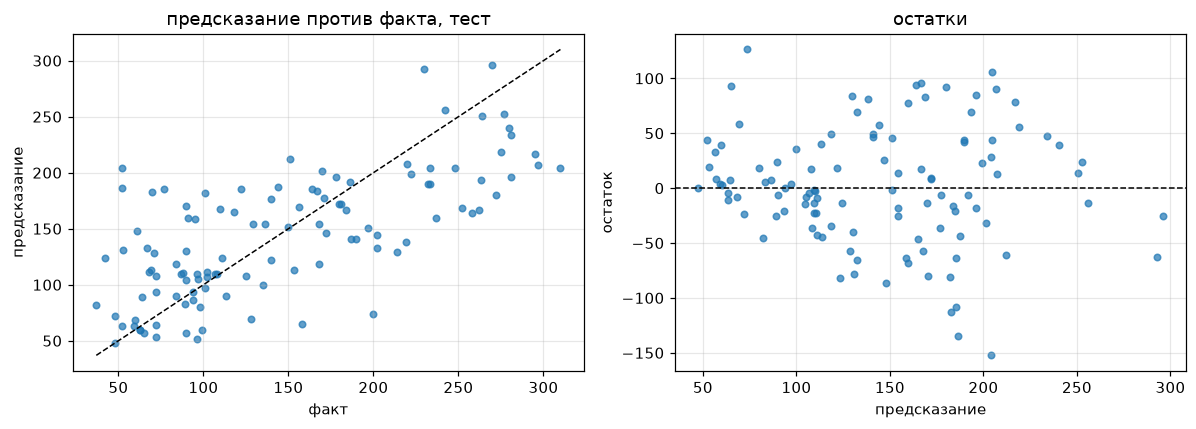

In [22]:
final = GridSearchCV(Pipeline([("sc", StandardScaler()), ("m", Lasso(max_iter=50000))]),
                     {"m__alpha": np.logspace(-2, 1.5, 60)},
                     scoring="r2", cv=cv_dia).fit(X_dia_tr, y_dia_tr)

coef = pd.Series(final.best_estimator_["m"].coef_, index=X_dia.columns)
print(f"alpha* = {final.best_params_['m__alpha']:.3f}")
print(f"R2 на отложенном тесте = {final.score(X_dia_te, y_dia_te):.3f}")
print()
print("коэффициенты на стандартизованных признаках:")
print(coef[coef.abs() > 0].sort_values(key=abs, ascending=False).round(2).to_string())
print(f"\nзануленo признаков: {(coef == 0).sum()} из {len(coef)} ({list(coef[coef == 0].index)})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pred_te = final.predict(X_dia_te)
axes[0].scatter(y_dia_te, pred_te, s=18, alpha=0.7)
lims = [y_dia_te.min(), y_dia_te.max()]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("факт")
axes[0].set_ylabel("предсказание")
axes[0].set_title("предсказание против факта, тест")
axes[1].scatter(pred_te, y_dia_te - pred_te, s=18, alpha=0.7)
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("предсказание")
axes[1].set_ylabel("остаток")
axes[1].set_title("остатки")
plt.tight_layout()
plt.show()

График остатков это обязательная проверка, которую метрики не заменяют. Смотреть надо на три вещи: остатки центрированы около нуля, их разброс не зависит от величины предсказания (гомоскедастичность), нет видимой кривизны. Кривизна означает, что линейная форма модели неадекватна и нужны нелинейные преобразования признаков. Расширяющийся веер означает гетероскедастичность, при которой доверительные интервалы коэффициентов посчитаны неверно, хотя предсказания сами по себе могут быть приемлемыми.

Здесь видна ещё одна деталь: на правом краю модель систематически занижает предсказание. Это следствие того, что целевая переменная ограничена снизу и скошена, а линейная модель с квадратичной потерей такого учесть не может.

# Часть IV. Логистическая регрессия и отбор признаков

## 4.1 Модель

Логистическая регрессия моделирует вероятность класса, а не сам класс:

$$P(y=1\mid x) = \sigma(\beta_0 + x^\top\beta), \qquad \sigma(z)=\frac{1}{1+e^{-z}}$$

Линейной является не вероятность, а логарифм отношения шансов:

$$\ln\frac{P(y=1\mid x)}{P(y=0\mid x)} = \beta_0 + x^\top\beta$$

Отсюда прямая интерпретация коэффициентов: увеличение $x_j$ на единицу умножает шансы на $e^{\beta_j}$. Это удобное свойство, которого нет у большинства нелинейных классификаторов, и одна из причин, по которой логистическую регрессию не вытесняют.

Коэффициенты подбираются максимизацией правдоподобия, что эквивалентно минимизации логистической функции потерь:

$$\mathcal{L}(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i\ln p_i + (1-y_i)\ln(1-p_i)\Big], \qquad p_i=\sigma(\beta_0+x_i^\top\beta)$$

Закрытого решения нет, оптимизация численная. Функция потерь выпуклая, поэтому глобальный минимум единственный.

Два факта, которые надо знать до обучения:

* **Полное разделение.** Если какая-то линейная комбинация признаков идеально разделяет классы, правдоподобие растёт монотонно при устремлении $\|\beta\|\to\infty$, оптимум уходит на бесконечность, коэффициенты расходятся. Это частая ситуация при $p$, близком к $n$. Регуляризация решает проблему полностью, поэтому в sklearn она включена по умолчанию.
* **В sklearn регуляризация включена всегда.** Параметр `C` это величина, **обратная** силе штрафа: $C = 1/\alpha$. Большое `C` означает слабую регуляризацию. Чтобы получить почти чистое максимальное правдоподобие, ставят `penalty=None` или очень большое `C`. Это противоположно интуиции из линейных моделей, где большой параметр означал сильный штраф.

## 4.2 Данные

Синтетическая задача с контролируемой структурой: 800 объектов, 30 признаков, из них 6 информативных и 8 избыточных (линейные комбинации информативных). Остальные 16 это шум. Дисбаланс классов 80 на 20, как в типичной задаче про отклик, дефолт или отказ оборудования.

In [23]:
X_clf, y_clf = make_classification(
    n_samples=800, n_features=30, n_informative=6, n_redundant=8, n_repeated=0,
    n_clusters_per_class=2, weights=[0.8, 0.2], flip_y=0.03, class_sep=0.9, random_state=SEED)

names_clf = [f"c{j:02d}" for j in range(30)]
X_clf_df = pd.DataFrame(X_clf, columns=names_clf)

X_ctr, X_cte, y_ctr, y_cte = train_test_split(X_clf, y_clf, test_size=0.25,
                                              stratify=y_clf, random_state=SEED)
print(f"обучение {X_ctr.shape}, тест {X_cte.shape}")
print(f"доля положительного класса: обучение {y_ctr.mean():.3f}, тест {y_cte.mean():.3f}")
print(f"базовая точность тривиального классификатора 'всегда 0': {1 - y_clf.mean():.3f}")

обучение (600, 30), тест (200, 30)
доля положительного класса: обучение 0.208, тест 0.205
базовая точность тривиального классификатора 'всегда 0': 0.792


Последняя строка задаёт правильную точку отсчёта. Классификатор, который всегда предсказывает мажоритарный класс, уже даёт 80% верных ответов, ничего не выучив. Любая метрика качества должна сравниваться именно с этим уровнем, а не с нулём.

## 4.3 Метрики классификации

Всё начинается с матрицы ошибок при фиксированном пороге (по умолчанию 0.5):

| | предсказан 0 | предсказан 1 |
|---|---|---|
| **факт 0** | TN | FP |
| **факт 1** | FN | TP |

$$\text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}, \quad F_1 = \frac{2\,PR}{P+R}$$

**Точность (accuracy) при дисбалансе бесполезна.** При 20% положительных классификатор "всегда 0" даёт accuracy 0.80. Модель с accuracy 0.82 может быть как лучше, так и хуже него, по одной этой цифре не сказать.

**Precision против recall это выбор цены ошибки.** Precision это доля верных среди сигналов тревоги, recall это доля пойманных из всех настоящих. Медицинский скрининг требует высокого recall (пропустить болезнь дороже ложной тревоги), спам-фильтр требует высокой precision (удалить письмо дороже пропущенного спама). $F_1$ это их гармоническое среднее, компромисс по умолчанию, но не универсальный: если цены ошибок различаются, честнее взвешенная $F_\beta$ или прямой учёт стоимости.

**Метрики, не зависящие от порога.** Precision, recall и accuracy зависят от выбранного порога. Есть метрики, оценивающие качество ранжирования на всех порогах сразу.

ROC AUC это площадь под кривой (recall против доли ложных тревог). Равна вероятности того, что случайный положительный объект получит больший скор, чем случайный отрицательный. 0.5 это случай, 1.0 это идеал. Удобна и популярна, но **при сильном дисбалансе завышает впечатление**: доля ложных тревог считается от большого числа отрицательных, поэтому даже сотни ложных срабатываний почти не двигают её.

PR AUC (average precision) это площадь под кривой precision-recall. При дисбалансе информативнее ROC AUC, потому что precision напрямую реагирует на ложные срабатывания. Базовый уровень для PR AUC это доля положительного класса (здесь 0.2), а не 0.5.

**Log loss и калибровка.** Если нужны сами вероятности, а не только порядок (расчёт ожидаемых потерь, ценообразование риска), качество ранжирования недостаточно. Log loss и Brier score штрафуют за неверные вероятности. Модель может иметь отличный AUC и при этом систематически завышать вероятности, тогда её решения по порогу окажутся неверными. Это проверяется калибровочной кривой.

Считаем всё на одной модели.

In [24]:
logit = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=5000, class_weight=None))]).fit(X_ctr, y_ctr)

proba = logit.predict_proba(X_cte)[:, 1]
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_cte, pred)

print("матрица ошибок (порог 0.5):")
print(pd.DataFrame(cm, index=["факт 0", "факт 1"], columns=["пред 0", "пред 1"]))
print()
print(f"accuracy      {accuracy_score(y_cte, pred):.3f}   (тривиальный: {1 - y_cte.mean():.3f})")
print(f"precision     {precision_score(y_cte, pred):.3f}")
print(f"recall        {recall_score(y_cte, pred):.3f}")
print(f"F1            {f1_score(y_cte, pred):.3f}")
print(f"ROC AUC       {roc_auc_score(y_cte, proba):.3f}")
print(f"PR AUC        {average_precision_score(y_cte, proba):.3f}   (базовый: {y_cte.mean():.3f})")
print(f"log loss      {log_loss(y_cte, proba):.3f}")
print(f"Brier         {brier_score_loss(y_cte, proba):.3f}")

матрица ошибок (порог 0.5):
        пред 0  пред 1
факт 0     153       6
факт 1      21      20

accuracy      0.865   (тривиальный: 0.795)
precision     0.769
recall        0.488
F1            0.597
ROC AUC       0.830
PR AUC        0.589   (базовый: 0.205)
log loss      0.386
Brier         0.120


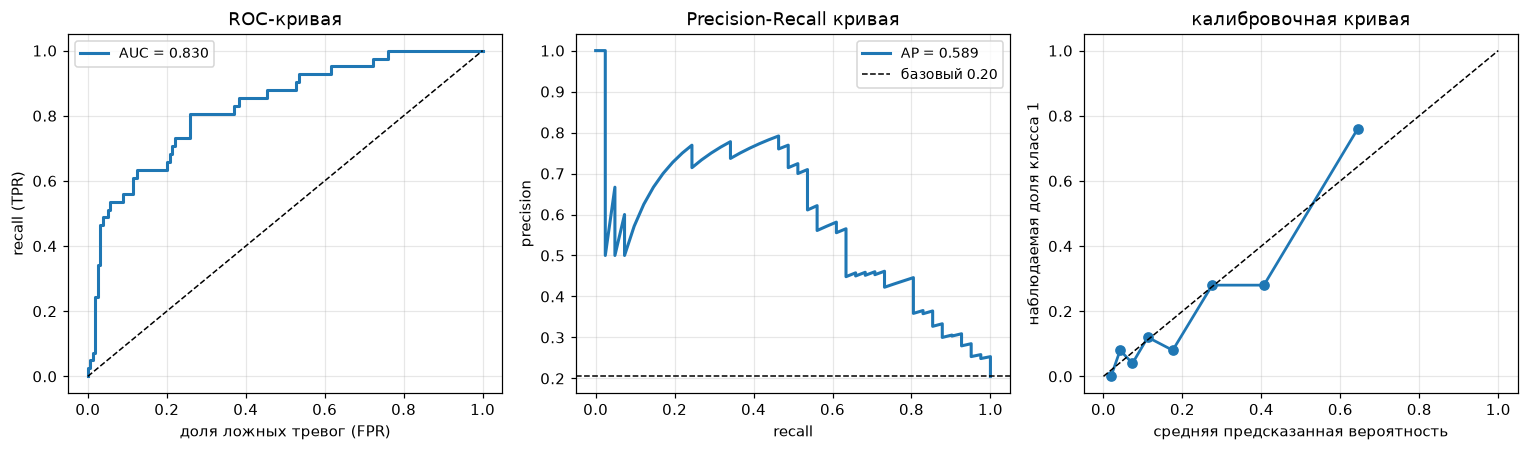

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

fpr, tpr, _ = roc_curve(y_cte, proba)
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_cte, proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("доля ложных тревог (FPR)")
axes[0].set_ylabel("recall (TPR)")
axes[0].set_title("ROC-кривая")
axes[0].legend(fontsize=9)

prec, rec, _ = precision_recall_curve(y_cte, proba)
axes[1].plot(rec, prec, lw=2, label=f"AP = {average_precision_score(y_cte, proba):.3f}")
axes[1].axhline(y_cte.mean(), color="k", ls="--", lw=1, label=f"базовый {y_cte.mean():.2f}")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall кривая")
axes[1].legend(fontsize=9)

frac_pos, mean_pred = calibration_curve(y_cte, proba, n_bins=8, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, "o-", lw=1.8)
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_xlabel("средняя предсказанная вероятность")
axes[2].set_ylabel("наблюдаемая доля класса 1")
axes[2].set_title("калибровочная кривая")
plt.tight_layout()
plt.show()

Калибровочная кривая логистической регрессии обычно лежит близко к диагонали: минимизация log loss напрямую оптимизирует качество вероятностей, поэтому модель откалибрована почти без дополнительных усилий. Это ещё одно её преимущество перед моделями, обученными на других потерях. Отклонения от диагонали, если они есть, означают, что предсказанным вероятностям нельзя доверять как вероятностям, даже когда ранжирование хорошее.

## 4.4 Порог принятия решения

Модель выдаёт вероятность, порог превращает её в решение. Порог 0.5 оптимален только тогда, когда цена ложной тревоги равна цене пропуска и классы сбалансированы. В реальных задачах не выполняется ни то, ни другое. Порог это отдельный параметр, и подбирать его надо под стоимость ошибок, а **не по обучающей выборке**.

Пройдём по всем порогам и посмотрим, как расходятся precision и recall.

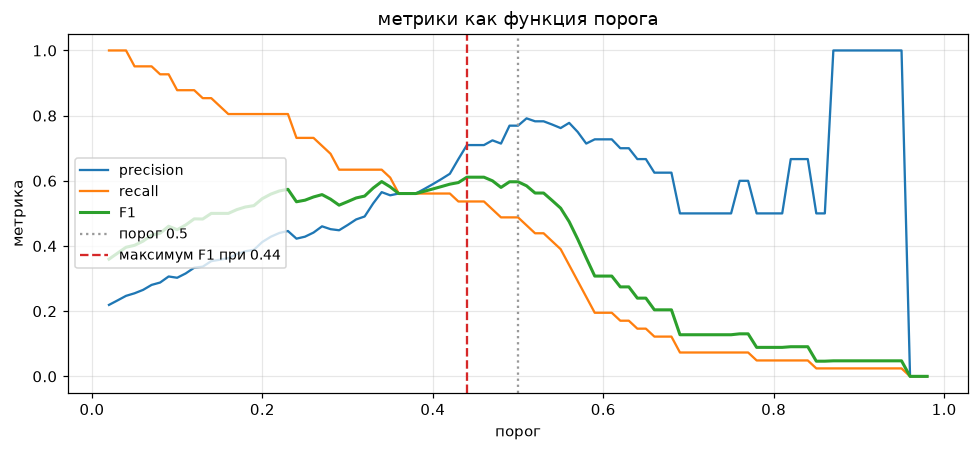

порог 0.5           : precision 0.769, recall 0.488, F1 0.597
порог 0.44 (max F1): precision 0.710, recall 0.537, F1 0.611


In [26]:
thr = np.linspace(0.02, 0.98, 97)
prec_t, rec_t, f1_t = [], [], []
for t in thr:
    p = (proba >= t).astype(int)
    prec_t.append(precision_score(y_cte, p, zero_division=0))
    rec_t.append(recall_score(y_cte, p, zero_division=0))
    f1_t.append(f1_score(y_cte, p, zero_division=0))

best = thr[int(np.argmax(f1_t))]
fig, ax = plt.subplots()
ax.plot(thr, prec_t, label="precision")
ax.plot(thr, rec_t, label="recall")
ax.plot(thr, f1_t, label="F1", lw=2)
ax.axvline(0.5, color="0.6", ls=":", label="порог 0.5")
ax.axvline(best, color="C3", ls="--", label=f"максимум F1 при {best:.2f}")
ax.set_xlabel("порог")
ax.set_ylabel("метрика")
ax.set_title("метрики как функция порога")
ax.legend(fontsize=9, loc="center left")
plt.tight_layout()
plt.show()

print(f"порог 0.5           : precision {prec_t[np.argmin(abs(thr-0.5))]:.3f}, "
      f"recall {rec_t[np.argmin(abs(thr-0.5))]:.3f}, F1 {f1_t[np.argmin(abs(thr-0.5))]:.3f}")
print(f"порог {best:.2f} (max F1): precision {max(zip(f1_t, prec_t))[1]:.3f}, "
      f"recall {dict(zip(f1_t, rec_t))[max(f1_t)]:.3f}, F1 {max(f1_t):.3f}")

При дисбалансе оптимальный по $F_1$ порог обычно ниже 0.5: понижая порог, мы соглашаемся на больше ложных тревог ради того, чтобы поймать больше объектов редкого класса. Насколько ниже, определяется не универсальным правилом, а соотношением стоимостей в конкретной задаче.

Про `class_weight="balanced"`: этот параметр домножает вклад каждого класса в функцию потерь обратно пропорционально его частоте, что эквивалентно сдвигу порога через смещение вероятностей. Он полезен, когда важен редкий класс, но у него есть цена: он **портит калибровку**, потому что модель обучается на искусственно перевзвешенных данных и её вероятности перестают соответствовать реальным частотам. Если нужны и хорошее качество на редком классе, и корректные вероятности, чище оставить веса как есть и настраивать порог отдельно.

## 4.5 Отбор признаков в логистической регрессии

Все три семейства работают так же, как в линейном случае, с заменой критериев.

* **Фильтр:** `f_classif` (дисперсионный анализ, линейная разделимость по одному признаку) или `mutual_info_classif`. Те же ограничения: изолированная оценка, слепота к взаимодействиям.
* **Обёртки:** RFE и последовательный отбор, критерий это ROC AUC или другая целевая метрика на кросс-валидации.
* **Встроенные:** L1-регуляризация (`penalty="l1"`, солвер `liblinear` или `saga`) зануляет коэффициенты и отбирает признаки; L2 сжимает без зануления; ElasticNet (`penalty="elasticnet"`, только `saga`) сочетает.

Разберём влияние силы регуляризации через путь коэффициентов по `C`.

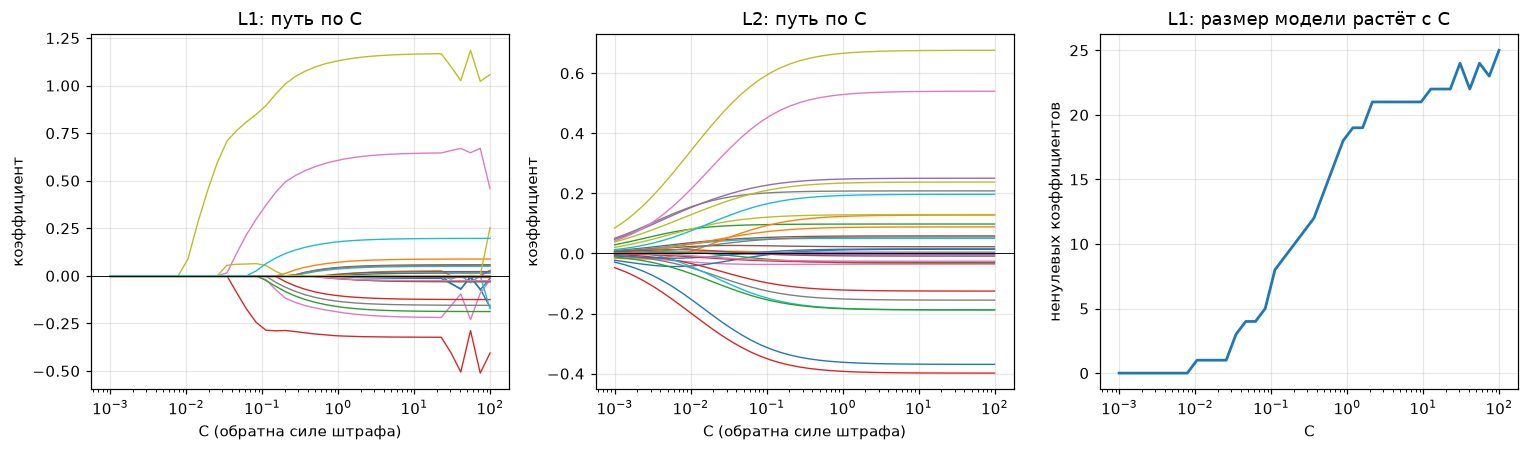

In [27]:
Xs_ctr = StandardScaler().fit(X_ctr).transform(X_ctr)
Cs = np.logspace(-3, 2, 40)

coef_l1 = np.array([LogisticRegression(penalty="l1", solver="liblinear", C=c, max_iter=5000)
                    .fit(Xs_ctr, y_ctr).coef_[0] for c in Cs])
coef_l2 = np.array([LogisticRegression(penalty="l2", C=c, max_iter=5000)
                    .fit(Xs_ctr, y_ctr).coef_[0] for c in Cs])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for j in range(30):
    axes[0].plot(Cs, coef_l1[:, j], lw=0.9)
    axes[1].plot(Cs, coef_l2[:, j], lw=0.9)
for ax, title in zip(axes[:2], ["L1: путь по C", "L2: путь по C"]):
    ax.set_xscale("log")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("C (обратна силе штрафа)")
    ax.set_ylabel("коэффициент")
    ax.set_title(title)

nnz = (np.abs(coef_l1) > 1e-6).sum(1)
axes[2].plot(Cs, nnz, lw=1.8)
axes[2].set_xscale("log")
axes[2].set_xlabel("C")
axes[2].set_ylabel("ненулевых коэффициентов")
axes[2].set_title("L1: размер модели растёт с C")
plt.tight_layout()
plt.show()

Читается зеркально к линейному случаю: слева (малое `C`, сильный штраф) модель почти пуста, справа (большое `C`, слабый штраф) в модели все признаки. У L1 линии обрываются в ноль по одной, у L2 плавно сходятся, не достигая его. При малом `C` даже L2-коэффициенты почти нулевые, но формально ненулевые: отбора нет.

## 4.6 Честное сравнение и подбор

Внешняя стратифицированная кросс-валидация, внутренняя подбирает гиперпараметры. Целевая метрика ROC AUC. Всё внутри Pipeline.

In [28]:
def scl(step):
    return Pipeline([("sc", StandardScaler()), *step])


LR = lambda **kw: LogisticRegression(max_iter=5000, **kw)
clf_setups = {
    "L2, все признаки": (scl([("clf", LR())]), {"clf__C": np.logspace(-3, 2, 20)}),
    "Фильтр + L2": (scl([("sel", SelectKBest(f_classif)), ("clf", LR())]),
                    {"sel__k": [4, 8, 14, 20, 30], "clf__C": np.logspace(-2, 2, 8)}),
    "RFE + L2": (scl([("sel", RFE(LR())), ("clf", LR())]),
                 {"sel__n_features_to_select": [4, 8, 14, 20], "clf__C": np.logspace(-2, 2, 6)}),
    "L1 (отбор внутри)": (scl([("clf", LR(penalty="l1", solver="liblinear"))]),
                          {"clf__C": np.logspace(-3, 2, 20)}),
    "ElasticNet": (scl([("clf", LR(penalty="elasticnet", solver="saga"))]),
                   {"clf__C": np.logspace(-2, 2, 8), "clf__l1_ratio": [0.2, 0.5, 0.8]}),
    "L1 отбор + L2 обучение": (scl([("sel", SelectFromModel(LR(penalty="l1", solver="liblinear"))),
                                    ("clf", LR())]),
                               {"sel__estimator__C": np.logspace(-2, 1, 8), "clf__C": np.logspace(-2, 2, 6)}),
}

outer_c = StratifiedKFold(5, shuffle=True, random_state=SEED)
inner_c = StratifiedKFold(4, shuffle=True, random_state=0)

rows = []
for name, (est, grid) in clf_setups.items():
    m = GridSearchCV(est, grid, scoring="roc_auc", cv=inner_c)
    s = cross_val_score(m, X_clf_df, y_clf, scoring="roc_auc", cv=outer_c)
    rows.append({"метод": name, "ROC AUC": s.mean(), "std по фолдам": s.std()})

print(pd.DataFrame(rows).sort_values("ROC AUC", ascending=False).to_string(index=False))

                 метод  ROC AUC  std по фолдам
            ElasticNet    0.830          0.034
           Фильтр + L2    0.829          0.037
              RFE + L2    0.824          0.037
     L1 (отбор внутри)    0.821          0.042
      L2, все признаки    0.817          0.021
L1 отбор + L2 обучение    0.815          0.042


Как и в регрессии, разница между разумными методами невелика на фоне разброса по фолдам. L1 привлекателен тем, что даёт компактную модель бесплатно, одним обучением, без внешнего перебора числа признаков. Связка "L1 для отбора, L2 для обучения" снимает смещение коэффициентов, внесённое L1, тем же приёмом, что и в линейном случае.

## 4.7 Отбор на реальных данных и сравнение мер важности

`breast_cancer`: 569 объектов, 30 признаков, диагноз злокачественной или доброкачественной опухоли. Признаки сильно коррелированы (радиус, периметр и площадь измеряют, по сути, размер), поэтому это хороший тест на устойчивость отбора.

Сравним три меры важности признака: модуль коэффициента L1-модели, важность по перестановкам (permutation importance) и частоту отбора по бутстрапу. Они отвечают на разные вопросы и не обязаны совпадать.

In [29]:
bc = load_breast_cancer(as_frame=True)
Xb, yb = bc.data, bc.target
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, stratify=yb, random_state=SEED)

l1_model = Pipeline([("sc", StandardScaler()),
                     ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=5000))]
                    ).fit(Xb_tr, yb_tr)
l1_coef = np.abs(l1_model["clf"].coef_[0])

perm = permutation_importance(l1_model, Xb_te, yb_te, scoring="roc_auc",
                              n_repeats=30, random_state=SEED)

rng = np.random.default_rng(SEED)
Xb_tr_arr = Xb_tr.values
freq = np.zeros(Xb.shape[1])
for _ in range(100):
    idx = rng.integers(0, len(Xb_tr_arr), len(Xb_tr_arr))
    m = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=5000))]
                 ).fit(Xb_tr_arr[idx], yb_tr.values[idx])
    freq += np.abs(m["clf"].coef_[0]) > 1e-8
freq /= 100

imp = pd.DataFrame({"|coef| L1": l1_coef, "perm (ROC AUC)": perm.importances_mean,
                    "частота отбора": freq}, index=Xb.columns)
print(imp.sort_values("частота отбора", ascending=False).head(14).round(3).to_string())
print(f"\nROC AUC L1-модели на тесте: {roc_auc_score(yb_te, l1_model.predict_proba(Xb_te)[:, 1]):.4f}")
print(f"ненулевых признаков: {(l1_coef > 1e-8).sum()} из {Xb.shape[1]}")

                      |coef| L1  perm (ROC AUC)  частота отбора
worst concave points      0.884           0.013            1.00
worst radius              2.052           0.145            0.99
worst texture             0.585           0.009            0.97
worst smoothness          0.204           0.002            0.92
mean concave points       0.534           0.005            0.89
worst symmetry            0.176           0.001            0.88
radius error              0.390           0.003            0.71
mean texture              0.000           0.000            0.43
worst area                0.000           0.000            0.20
worst perimeter           0.000           0.000            0.18
worst concavity           0.000           0.000            0.16
area error                0.000           0.000            0.09
mean concavity            0.000           0.000            0.05
mean symmetry             0.000           0.000            0.04

ROC AUC L1-модели на тесте: 0.9973
нену

Три меры расходятся, и каждое расхождение содержательно.

* **Модуль коэффициента** это вклад признака в линейный предсказатель при данном наборе остальных. У коллинеарных признаков он делится между ними произвольно: один может получить большой коэффициент, его почти-копия околонулевой, хотя информативны оба одинаково.
* **Permutation importance** измеряет падение качества при разрушении признака **в присутствии остальных**. Если у признака есть коррелированный дублёр, модель компенсирует потерю через него, и важность обоих окажется заниженной. Это не баг, а корректный ответ на вопрос "что даёт этот признак сверх остальных", который для дублирующихся данных близок к нулю.
* **Частота отбора по бутстрапу** показывает воспроизводимость. Если два признака делят частоту примерно поровну, они взаимозаменяемы, и любой единичный прогон выберет одного случайно.

Ни одна из трёх мер не является правильной сама по себе, они отвечают на разные вопросы. Для решения "какие признаки перестать собирать" смотрят на permutation importance и частоту вместе: убирать можно то, что стабильно неважно по обеим. Для интерпретации "как признак влияет на исход" осторожность обязательна: при мультиколлинеарности коэффициент отдельного признака не имеет надёжной интерпретации, о чём предупреждала часть 1.3.

## 4.8 Кривые обучения: данных мало или модель проста

Последний диагностический инструмент. Кривая обучения показывает качество на обучении и на валидации как функцию размера выборки. Она отвечает на вопрос, который метрики не решают: упёрлись мы в недостаток данных или в недостаток сложности модели.

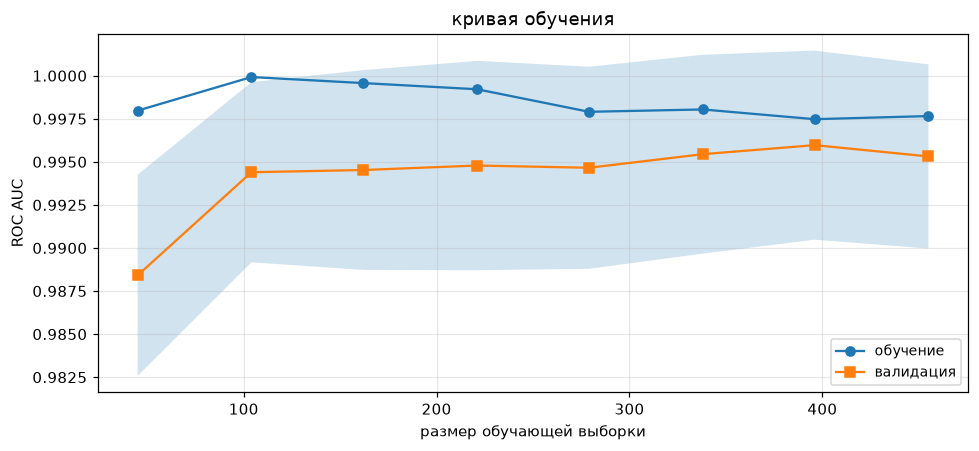

In [30]:
sizes, tr_s, va_s = learning_curve(
    Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(C=1.0, max_iter=5000))]),
    Xb, yb, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring="roc_auc", train_sizes=np.linspace(0.1, 1.0, 8))

fig, ax = plt.subplots()
ax.plot(sizes, tr_s.mean(1), "o-", label="обучение")
ax.fill_between(sizes, va_s.mean(1) - va_s.std(1), va_s.mean(1) + va_s.std(1), alpha=0.2)
ax.plot(sizes, va_s.mean(1), "s-", label="валидация")
ax.set_xlabel("размер обучающей выборки")
ax.set_ylabel("ROC AUC")
ax.set_title("кривая обучения")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Чтение кривой обучения:

* **Кривые сошлись на низком уровне** (высокое смещение): модель слишком проста, добавление данных не поможет. Нужны более богатые признаки, взаимодействия, нелинейность или менее сильная регуляризация.
* **Между кривыми стабильный разрыв, валидационная всё ещё растёт** (высокий разброс): модель переобучается, но данные помогают. Стоит собрать больше данных, усилить регуляризацию или сократить число признаков.
* **Кривые сошлись на высоком уровне:** модель адекватна объёму данных, дальнейшие вложения в данные того же типа малорентабельны.

На этих данных обучающая и валидационная кривые сходятся к высокому уровню уже на нескольких сотнях объектов: задача для логистической регрессии простая, данных достаточно, отбор признаков здесь вопрос компактности и интерпретируемости, а не качества.

# Часть V. Сводка

## 5.1 Три семейства методов отбора

| Свойство | Фильтры | Обёртки | Встроенные |
|---|---|---|---|
| Принцип | статистика признак-цель | перебор подмножеств по CV | штраф в функции потерь |
| Примеры | F-тест, MI, порог дисперсии | forward, backward, RFE | Lasso, ElasticNet, L1-logit |
| Учёт взаимодействий | нет | да | частично |
| Убирает дубликаты | нет | да | Lasso произвольно, ElasticNet группой |
| Стоимость | $O(p)$ | $O(p)$ .. $O(p^2)$ обучений | одно обучение |
| Привязка к модели | нет | к любой | к линейной |
| Риск переобучить отбор | низкий | высокий | средний |
| Когда применять | десятки тысяч признаков, первый отсев | сотни признаков, важна метрика | базовый выбор для линейных моделей |

Практический порядок действий: грубый отсев фильтром, если признаков очень много; затем L1 или ElasticNet как основной механизм; обёртки только если признаков немного и нужна оптимизация под конкретную метрику; отбор по устойчивости, если результат влияет на решения о сборе данных.

## 5.2 Регуляризация

| | Ridge (L2) | Lasso (L1) | ElasticNet |
|---|---|---|---|
| Зануляет коэффициенты | нет | да | да |
| Отбор признаков | нет | да | да |
| При $p>n$ | работает | не более $n$ признаков | работает |
| Коллинеарная группа | делит вклад поровну | берёт одного произвольно | берёт группой |
| Закрытая форма | есть | нет | нет |
| Когда | все признаки полезны, важна устойчивость | нужна разреженность | коллинеарность плюс разреженность |

## 5.3 Валидация: чек-лист

1. Метрика выбрана из задачи и зафиксирована **до** экспериментов.
2. Всё, что настраивается по данным (масштабирование, заполнение пропусков, отбор, кодирование, порог), находится внутри `Pipeline`.
3. Кросс-валидация оценивает **весь** конвейер, а не только финальную модель.
4. Классификация: стратификация. Группы: `GroupKFold`. Время: `TimeSeriesSplit`.
5. Гиперпараметры подбираются во внутренней CV, качество оценивается во внешней (вложенная схема).
6. Смотрим не только на среднее по фолдам, но и на разброс: разница меньше разброса не является разницей.
7. Тестовая выборка используется один раз, в самом конце. Каждое обращение к ней для решений превращает её в валидационную.

## 5.4 Типичные ошибки

| Ошибка | Следствие | Правильно |
|---|---|---|
| Отбор признаков на всех данных до CV | оптимистичная оценка (раздел 2.3) | отбор внутри Pipeline, внутри фолда |
| `fit` масштабировщика на всех данных | утечка статистик теста | `fit` только на обучающей части фолда |
| Регуляризация без стандартизации | штраф зависит от единиц измерения | `StandardScaler` перед регуляризацией |
| Accuracy при дисбалансе | иллюзия качества выше тривиального уровня | ROC AUC, PR AUC, сравнение с базой |
| Отчёт по лучшему результату сетки | смещение от выбора (раздел 2.4) | вложенная CV |
| Один замер на одном split | оценка тонет в разбросе разбиения | CV, разброс по фолдам |
| Интерпретация коэффициентов при коллинеарности | нестабильные знаки и величины | проверить VIF, отбор по устойчивости |
| ROC AUC при сильном дисбалансе как единственная метрика | завышенное впечатление | добавить PR AUC |
| Порог 0.5 по умолчанию | неоптимальные решения при дисбалансе или разной цене ошибок | подбор порога под стоимость, не на обучении |

## 5.5 Почему именно линейные модели

Линейная и логистическая регрессия остаются рабочим инструментом не из-за простоты, а из-за набора свойств, которых нет вместе ни у одной другой модели: интерпретируемые коэффициенты (в логистической это логарифмы отношения шансов), выпуклая функция потерь с единственным минимумом, честные вероятности из коробки, прозрачная связь регуляризации с отбором признаков, дешёвое обучение и предсказание. На табличных данных с преимущественно линейными зависимостями хорошо отрегуляризованная линейная модель регулярно оказывается вровень с градиентным бустингом, оставаясь при этом полностью объяснимой. Отбор признаков и корректная валидация это то, что превращает её из учебного примера в надёжный продакшн-инструмент.